# Assignment Module 2: Pet Classification

| ID  | Student       | Email                  |
|-----|---------------|------------------------|
| 0001157160  | Battistoni Leandro   | leandro.battistoni@studio.unibo.it|
| 0001189368   | Ponzuoli Giovanni   | giovanni.ponzuoli@studio.unibo.it|
| 0001189110   | Rimondi Simone   | simone.rimondi5@studio.unibo.it|

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.

## Imports, Device Selection and Fix Random Seed

In this section, we import the necessary libraries, select the appropriate computing device (GPU if available, otherwise CPU), and fix the random seed to ensure the reproducibility of the notebook's results. Reproducibility is critical when developing and evaluating machine learning models, as it guarantees consistent behavior across multiple runs.

In [ ]:
!pip install torchinfo

In [ ]:
import os
import math
import random
import shutil
import tarfile
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torch.utils.flop_counter import FlopCounterMode
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from torchvision import transforms as T
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights, resnet18, ResNet18_Weights
from torchvision.utils import make_grid
import torchvision.transforms.functional as TF

from torchinfo import summary
from tqdm import tqdm, notebook as tqdm_notebook

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def fix_random(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(seed=115)

## Utility Functions

This section contains the definitions of utility functions used throughout the notebook. These functions are designed to simplify and modularize common operations, making the code more readable and reusable.

### Exploratory Data Analysis

In [ ]:
def show_random_images(images_path = "ipcv-assignment-2/dataset/images", num_images = 16):
    images_dir = Path(images_path)
    all_images = list(images_dir.glob("*.jpg"))
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    cols = 4
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

    fig.suptitle("Random Images", fontsize=16)

    for ax, img_path in zip(axes.flat, selected_images):
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
            ax.set_title(img_path.stem, fontsize=10)
        except Exception as e:
            ax.set_visible(False)
            print(f"Error loading image {img_path.name}: {e}")


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


def collect_image_paths(dataset_or_path):
    if isinstance(dataset_or_path, (str, Path)):
        # Case 1: simple directory
        image_dir = Path(dataset_or_path)
        image_paths = list(image_dir.glob("*.jpg"))
    else:
        # Case 2: OxfordPetDataset (custom class)
        if hasattr(dataset_or_path, "root") and hasattr(dataset_or_path, "names"):
            image_paths = [
                dataset_or_path.root / "images" / f"{name}.jpg"
                for name in dataset_or_path.names
            ]
        else:
            raise ValueError("Unsupported dataset type: expected OxfordPetDataset or path.")

    if not image_paths:
        raise FileNotFoundError("No images found in dataset or directory.")

    return image_paths


def run_eda_on_image_sizes(dataset_or_path):
    image_paths = collect_image_paths(dataset_or_path)

    sizes = []
    for img_path in tqdm(image_paths, desc="Analyzing image sizes"):
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                sizes.append({
                    "filename": Path(img_path).name,
                    "width": width,
                    "height": height,
                    "aspect_ratio": round(width / height, 2)
                })
        except Exception as e:
            print(f"Error on {img_path}: {e}")

    df = pd.DataFrame(sizes)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("EDA on Image Sizes", fontsize=16)

    # Histogram
    sns.histplot(df["width"], color="skyblue", label="Width", kde=True, ax=axes[0, 0])
    sns.histplot(df["height"], color="salmon", label="Height", kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Distribution of Image Width and Height")
    axes[0, 0].set_xlabel("Pixels")
    axes[0, 0].set_xlim([0, 800])
    axes[0, 0].legend()

    # Scatter plot
    sns.scatterplot(data=df, x="width", y="height", alpha=0.6, ax=axes[0, 1])
    axes[0, 1].set_title("Width vs Height")
    axes[0, 1].set_xlabel("Width (px)")
    axes[0, 1].set_ylabel("Height (px)")

    # Histogram
    sns.histplot(df["aspect_ratio"], bins=30, kde=True, color="mediumseagreen", ax=axes[1, 0])
    axes[1, 0].set_title("Aspect Ratio Distribution (width / height)")
    axes[1, 0].set_xlabel("Aspect Ratio")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("Descriptive statistics of image dimensions:")
    display(df[["width", "height", "aspect_ratio"]].describe())


def run_eda_on_colors(dataset_or_path):
    image_paths = collect_image_paths(dataset_or_path)

    color_data = []
    for path in tqdm(image_paths, desc="Analyzing colors"):
        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
                np_img = np.array(img) / 255.0  # Normalize to [0,1]

                color_data.append({
                    "filename": Path(path).name,
                    "R_mean": np.mean(np_img[:, :, 0]),
                    "G_mean": np.mean(np_img[:, :, 1]),
                    "B_mean": np.mean(np_img[:, :, 2])
                })
        except Exception as e:
            print(f"Error processing {path}: {e}")

    df_colors = pd.DataFrame(color_data)

    # --- Visualization ---
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("EDA on Image Colors", fontsize=16)

    # RGB mean distributions
    sns.histplot(df_colors["R_mean"], color="red", label="R", kde=True, ax=axes[0])
    sns.histplot(df_colors["G_mean"], color="green", label="G", kde=True, ax=axes[0])
    sns.histplot(df_colors["B_mean"], color="blue", label="B", kde=True, ax=axes[0])
    axes[0].set_title("Distribution of Mean RGB Values")
    axes[0].set_xlabel("Value")
    axes[0].legend()

    # Correlation heatmap
    corr = df_colors[["R_mean", "G_mean", "B_mean"]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
    axes[1].set_title("Correlation Between Channels")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Summary statistics ---
    print("Descriptive statistics of RGB mean values:")
    display(df_colors[["R_mean", "G_mean", "B_mean"]].describe())



def run_eda(dataset, class_names):
    print("Total number of images:", len(dataset))
    print("Number of classes:", dataset.get_num_classes())

    labels = [label for _, label in tqdm(dataset, desc="Extracting labels")]
    label_counts = Counter(labels)
    df_labels = pd.DataFrame({
        'Class': [class_names[i] for i in label_counts.keys()],
        'Count': list(label_counts.values())
    }).sort_values("Count", ascending=False)

    # Plot class distribution
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_labels, x='Class', y='Count', palette='viridis')
    plt.xticks(rotation=90)
    plt.title("Class Distribution")
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.show()


### Data Augmentation

In [ ]:
def visualize_transforms(img_path, mean, std):

    img = Image.open(img_path).convert("RGB")

    #transformations
    crop = transforms.RandomResizedCrop(128, scale=(0.8, 1.2))
    hflip = transforms.RandomHorizontalFlip(p=1)
    rotate = transforms.RandomRotation(30)
    color = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    affine = transforms.RandomAffine(0, translate=(0.1, 0.1))
    to_tensor = transforms.ToTensor()
    normalize = transforms.Normalize(mean, std)
    erasing = transforms.RandomErasing(p=1, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random')

    #Apply transformations step by step
    steps = [("Original", img)]

    img1 = crop(img)
    steps.append(("RandomResizedCrop", img1))

    img2 = hflip(img1)
    steps.append(("RandomHorizontalFlip", img2))

    img3 = rotate(img2)
    steps.append(("RandomRotation", img3))

    img4 = color(img3)
    steps.append(("ColorJitter", img4))

    img5 = affine(img4)
    steps.append(("RandomAffine", img5))

    img_tensor = to_tensor(img5)

    img_norm = normalize(img_tensor.clone())
    steps.append(("Normalize", img_norm))

    img_erase = erasing(img_norm.clone())
    steps.append(("RandomErasing", img_erase))

    # Plot
    n_cols = math.ceil(len(steps) / 2)
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
    axes = axes.flatten()

    for ax, (title, image) in zip(axes, steps):
        if isinstance(image, torch.Tensor):
            img_np = image.clone().detach()
            for t, m, s in zip(img_np, mean, std):
                t.mul_(s).add_(m)
            img_np = img_np.permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 1)
            ax.imshow(img_np)
        else:
            ax.imshow(image)
        ax.set_title(title, fontsize=10)
        ax.axis("on")
        ax.grid(False)

    # Turn off extra subplots
    for i in range(len(steps), len(axes)):
        axes[i].axis('off')

    plt.grid(False)
    plt.tight_layout()
    plt.show()


def visualize_mixup(img1, img2, label1, label2, lam, num_classes=37, resize_dim=128):

    preprocess = transforms.Compose([
        transforms.Resize((resize_dim, resize_dim)),
        transforms.ToTensor()
    ])

    img1 = preprocess(img1)
    img2 = preprocess(img2)

    mixed_img = lam * img1 + (1 - lam) * img2

    if num_classes is not None:
        onehot1 = torch.zeros(num_classes)
        onehot2 = torch.zeros(num_classes)
        onehot1[label1] = 1
        onehot2[label2] = 1
        mixed_label = lam * onehot1 + (1 - lam) * onehot2
        label_text = f"Mixed Label:\n{mixed_label.numpy().round(2)}"
    else:
        mixed_label = lam * label1 + (1 - lam) * label2
        label_text = f"Mixed Label: {mixed_label:.2f}"

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img1.permute(1, 2, 0).numpy())
    axes[0].set_title(f"Image 1\nLabel: {label1}")
    axes[0].axis("on")
    axes[0].grid(False)

    axes[1].imshow(img2.permute(1, 2, 0).numpy())
    axes[1].set_title(f"Image 2\nLabel: {label2}")
    axes[1].axis("on")
    axes[1].grid(False)

    axes[2].imshow(mixed_img.permute(1, 2, 0).numpy())
    axes[2].set_title(f"MixUp\nλ = {lam:.2f}")
    axes[2].axis("on")
    axes[2].grid(False)


    plt.tight_layout()
    plt.show()

    print(f"{label_text}")

### FLOPs Calculator Function

In [ ]:
def model_stats(model, input_shape, device=None, backward_multiplier=2.5):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    model_info = summary(
        model,
        input_size=input_shape,
        verbose=0,
        device=device
    )

    total_params = model_info.total_params
    trainable_params = model_info.trainable_params
    non_trainable_params = total_params - trainable_params

    #Compute FLOPs using PyTorch's FlopCounterMode
    dummy_input = torch.randn(input_shape).to(device)
    flop_counter = FlopCounterMode(model, display=False)
    with flop_counter:
        _ = model(dummy_input)
    forward_flops = flop_counter.get_total_flops()

    #Estimate backward FLOPs (only for trainable layers)
    trainable_ratio = trainable_params / total_params if total_params > 0 else 0.0
    backward_flops = forward_flops * backward_multiplier * trainable_ratio
    total_flops = forward_flops + backward_flops

    # Convert to MFLOPs for readability
    forward_flops_m = forward_flops / 1e6
    backward_flops_m = backward_flops / 1e6
    total_flops_m = total_flops / 1e6

    #Print clean summary
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Non-trainable params: {non_trainable_params:,}")

    print(f"Forward FLOPs: {forward_flops_m:.2f} MFLOPs")
    print(f"Backward FLOPs (trainable layers only): {backward_flops_m:.2f} MFLOPs")
    print(f"Total FLOPs per image: {total_flops_m:.2f} MFLOPs")

    #Return results as a dict
    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "forward_FLOPs_M": forward_flops_m,
        "backward_FLOPs_M": backward_flops_m,
        "total_FLOPs_M": total_flops_m,
    }

### Training and Validation

In [ ]:
def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()
        elif isinstance(layer, nn.Sequential):
            for sublayer in layer:
                if hasattr(sublayer, 'reset_parameters'):
                    sublayer.reset_parameters()

def accuracy(output, target):
    preds = output.argmax(dim=1)
    return (preds == target).float().mean()

def train_epoch(model, loader, criterion, optimizer, scheduler=None, mixup_alpha=0.4):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        if mixup_alpha > 0:
            # MixUp
            imgs, targets_a, targets_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
            outputs = model(imgs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)

            # Accuracy with mixup
            preds = outputs.argmax(dim=1)
            acc = lam * preds.eq(targets_a).sum() + (1 - lam) * preds.eq(targets_b).sum()
            acc = acc.item() / imgs.size(0)
        else:
            # Standard training
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            acc = preds.eq(labels).sum().item() / imgs.size(0)

        loss.backward()
        optimizer.step()

        if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        running_loss += loss.item() * imgs.size(0)
        running_acc += acc * imgs.size(0)

    return running_loss / len(loader.dataset), running_acc / len(loader.dataset)

def val_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0
    running_acc = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            running_acc += accuracy(outputs, labels).item() * imgs.size(0)
    return running_loss / len(loader.dataset), running_acc / len(loader.dataset)


def mixup_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

### Training Loop

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs,
                mix_up=0.4, mixup_start_epoch=10, device='cuda', save_path="best_model.pth", history_prefix="history"):

    #reset_weights(model)

    model.to(device)
    best_val_acc = 0.0

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    learning_rates = []

    for epoch in range(num_epochs):
        mixup_alpha = mix_up if epoch >= mixup_start_epoch else 0.0

        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer,
            scheduler=scheduler, mixup_alpha=mixup_alpha
        )
        val_loss, val_acc = val_epoch(model, val_loader, criterion)

        current_lr = optimizer.param_groups[0]['lr']
        if scheduler and not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        # Logging
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train loss: {train_loss:.4f}, accuracy: {train_acc:.4f}")
        print(f"  Val   loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")
        print(f"  Learning rate: {current_lr:.6f}")

        # Saving History
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        learning_rates.append(current_lr)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    # Save training history
    os.makedirs("history", exist_ok=True)
    torch.save(train_losses, f"{history_prefix}_train_losses.pt")
    torch.save(val_losses, f"{history_prefix}_val_losses.pt")
    torch.save(train_accuracies, f"{history_prefix}_train_accuracies.pt")
    torch.save(val_accuracies, f"{history_prefix}_val_accuracies.pt")
    torch.save(learning_rates, f"{history_prefix}_learning_rates.pt")

    print("Training complete. History saved.")

    return train_losses, val_losses, train_accuracies, val_accuracies, learning_rates

### Plotting and Comparison

In [ ]:
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=True, mixup_start_epoch = 10):

    epochs = range(1, len(train_losses) + 1)
    mixup_start_epoch = mixup_start_epoch

    plt.figure(figsize=(15, 10))

    # Loss plot
    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()
    plt.grid(True)

    #Draw the mix-up arrow
    if mixup:
      if mixup_start_epoch <= len(train_losses):
          y = train_losses[mixup_start_epoch - 1]
          plt.annotate("MixUp starts here",
                      xy=(mixup_start_epoch, y),
                      xytext=(mixup_start_epoch -15, y -1),
                      arrowprops=dict(facecolor='black', shrink=0.05),
                      fontsize=10,
                      bbox=dict(boxstyle="round", fc="w"))

    # Accuracy plot
    plt.subplot(2, 2, 2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()
    plt.grid(True)

    if mixup:
      if mixup_start_epoch <= len(train_accuracies):
          y = train_accuracies[mixup_start_epoch - 1]
          plt.annotate("MixUp starts here",
                      xy=(mixup_start_epoch, y),
                      xytext=(mixup_start_epoch -15, y +0.25),
                      arrowprops=dict(facecolor='black', shrink=0.05),
                      fontsize=10,
                      bbox=dict(boxstyle="round", fc="w"))

    # Learning rate plot
    plt.subplot(2, 2, 3)
    plt.plot(epochs, learning_rates, label="Learning Rate", color="orange")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.title("Learning Rate over Epochs")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def create_stats_dataframe(stats, labels, relative=False):
    df = pd.DataFrame(stats)
    df.insert(0, "Name", labels)

    # Rename columns
    df = df.rename(columns={
        "test_accuracy": "Test Accuracy",
        "trainable_params": "Parameters",
        "total_FLOPs_M": "MFLOPs"
    })

    df = df[["Name", "Test Accuracy", "Parameters", "MFLOPs"]]

    # Compute percent changes
    if not relative:
        # Baseline = first row
        baseline_acc = df.loc[0, "Test Accuracy"]
        baseline_params = df.loc[0, "Parameters"]
        baseline_flops = df.loc[0, "MFLOPs"]

        df["% Change (Accuracy)"] = ((df["Test Accuracy"] - baseline_acc) / baseline_acc) * 100
        df["% Change (Parameters)"] = ((df["Parameters"] - baseline_params) / baseline_params) * 100
        df["% Change (FLOPs)"] = ((df["MFLOPs"] - baseline_flops) / baseline_flops) * 100
    else:
        # Compare each row to the one above
        df["% Change (Accuracy)"] = df["Test Accuracy"].pct_change() * 100
        df["% Change (Parameters)"] = df["Parameters"].pct_change() * 100
        df["% Change (FLOPs)"] = df["MFLOPs"].pct_change() * 100

    # Round for readability
    df = df.round({
        "Test Accuracy": 2,
        "% Change (Accuracy)": 2,
        "% Change (Parameters)": 2,
        "% Change (FLOPs)": 2
    })

    # Reorder columns
    df = df[[
        "Name", "Test Accuracy", "% Change (Accuracy)",
        "Parameters", "% Change (Parameters)",
        "MFLOPs", "% Change (FLOPs)"
    ]]

    # Custom formatter that adds "+" for positive values
    def fmt_pct(x):
        if pd.isna(x):
            return ""
        return f"{x:+.2f}%"

    # Style and formatting
    styled = (
        df.style
        .format({
            "Test Accuracy": "{:.2f}",
            "% Change (Accuracy)": fmt_pct,
            "Parameters": "{:,.0f}",
            "% Change (Parameters)": fmt_pct,
            "MFLOPs": "{:,.0f}",
            "% Change (FLOPs)": fmt_pct
        })
        .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
        .set_properties(**{"text-align": "center"})
    )

    return styled


def plot_training_results(train_accuracies, val_accuracies, train_losses, val_losses, labels, colors=None, linestyles=None, figsize=(20, 10)):

    epochs = range(1, len(train_accuracies[0]) + 1)
    plt.figure(figsize=figsize)

    # Training Accuracy
    plt.subplot(2, 2, 1)
    for i, acc in enumerate(train_accuracies):
        plt.plot(epochs, acc, label=labels[i], color=colors[i],
                 linestyle=linestyles[i], linewidth=2 if i == 0 else 1)
    plt.title("Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Validation Accuracy
    plt.subplot(2, 2, 2)
    for i, acc in enumerate(val_accuracies):
        plt.plot(epochs, acc, label=labels[i], color=colors[i],
                 linestyle=linestyles[i], linewidth=2 if i == 0 else 1)
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Training Loss
    plt.subplot(2, 2, 3)
    for i, loss in enumerate(train_losses):
        plt.plot(epochs, loss, label=labels[i], color=colors[i],
                 linestyle=linestyles[i], linewidth=2 if i == 0 else 1)
    plt.title("Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Validation Loss
    plt.subplot(2, 2, 4)
    for i, loss in enumerate(val_losses):
        plt.plot(epochs, loss, label=labels[i], color=colors[i],
                 linestyle=linestyles[i], linewidth=2 if i == 0 else 1)
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_test_accuracies(test_accuracies, labels, colors=None, highlight_index=0, figsize=(10, 6), ylim=(0, 105), title="Best Test Accuracy for Each Model"):

    baseline = test_accuracies[highlight_index]
    percent_changes = [(acc - baseline) / baseline * 100 for acc in test_accuracies]

    plt.figure(figsize=figsize)
    bars = plt.bar(labels, test_accuracies, color=colors[:len(labels)])

    if highlight_index is not None and 0 <= highlight_index < len(bars):
        bars[highlight_index].set_edgecolor('gold')
        bars[highlight_index].set_linewidth(3)

    for bar, acc, change in zip(bars, test_accuracies, percent_changes):
        height = bar.get_height()
        change_text = f"{change:+.2f}%" if bar != bars[highlight_index] else "Baseline"
        plt.text(bar.get_x() + bar.get_width() / 2.0, height + 2,
                 f"{acc:.2f}\n({change_text})",
                 ha='center', va='bottom', fontsize=10)

    plt.ylim(*ylim)
    plt.title(title)
    plt.ylabel("Accuracy (%)")
    plt.xticks(rotation= 45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Test

In [ ]:
def test_epoch(model, loader, class_names=None):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    text = f" Test Accuracy: {acc:.4f} "
    border = "*" * (len(text) + 4)

    print(border)
    print(f"*{text}*")
    print(border)

    return acc

## Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.

In [ ]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git

Cloning into 'ipcv-assignment-2'...
remote: Enumerating objects: 7371, done.
remote: Total 7371 (delta 0), reused 0 (delta 0), pack-reused 7371 (from 1)
Receiving objects: 100% (7371/7371), 753.77 MiB | 20.02 MiB/s, done.
Updating files: 100% (7396/7396), done.


In [ ]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [ ]:
train_dataset = OxfordPetDataset(split="train", transform=None)
test_dataset = OxfordPetDataset(split="test", transform=None)
val_dataset = OxfordPetDataset(split="val", transform=None)

class_names = [
    'Abyssinian', 'American_Bulldog', 'American_Pit_Bull_Terrier',
    'Basset_Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay',
    'Boxer', 'British_Shorthair', 'Chihuahua', 'Egyptian_Mau',
    'English_Cocker_Spaniel', 'English_Setter', 'German_Shorthaired',
    'Great_Pyrenees', 'Havanese', 'Japanese_Chin', 'Keeshond',
    'Leonberger', 'Maine_Coon', 'Miniature_Pinscher', 'Newfoundland',
    'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian_Blue',
    'Saint_Bernard', 'Samoyed', 'Scottish_Terrier', 'Shiba_Inu',
    'Siamese', 'Sphynx', 'Staffordshire_Bull_Terrier',
    'Wheaten_Terrier', 'Yorkshire_Terrier']

# **Part 1: design your own network**

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

## Exploratory Data Analysis

Before training any model, we performed an initial **Exploratory Data Analysis (EDA)** to better understand the characteristics of the Oxford-IIIT Pet dataset. This study focused on three main aspects:

1. **Image Dimensions**  
   The dataset contains images with varying resolutions and aspect ratios. This variability requires preprocessing steps to resize all images to a uniform shape, which is essential for batch processing in convolutional neural networks.

2. **Color Distribution**  
   An analysis of the pixel values across the RGB channels showed that the color distribution is reasonably well-centered and consistent. Interestingly, the mean and standard deviation values are quite close to those used in standard pretrained models like ResNet. This suggests that leveraging transfer learning with ImageNet-pretrained weights may be appropriate for this dataset.

3. **Dataset Splits**  
   The dataset is split into approximately 50% for training, 25% for validation, and 25% for testing. Each split maintains a balanced distribution of the classes, ensuring that all pet breeds are equally represented across training and evaluation phases.

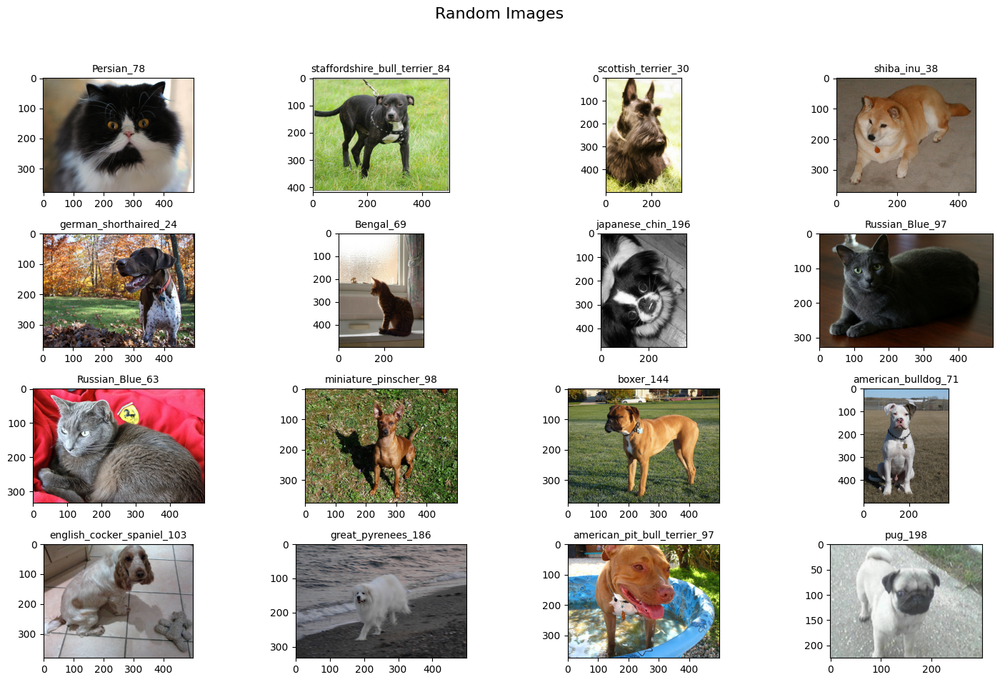

In [ ]:
show_random_images()

### EDA on Image Sizes

Analyzing image sizes: 100%|██████████| 7390/7390 [00:01<00:00, 6994.14it/s]


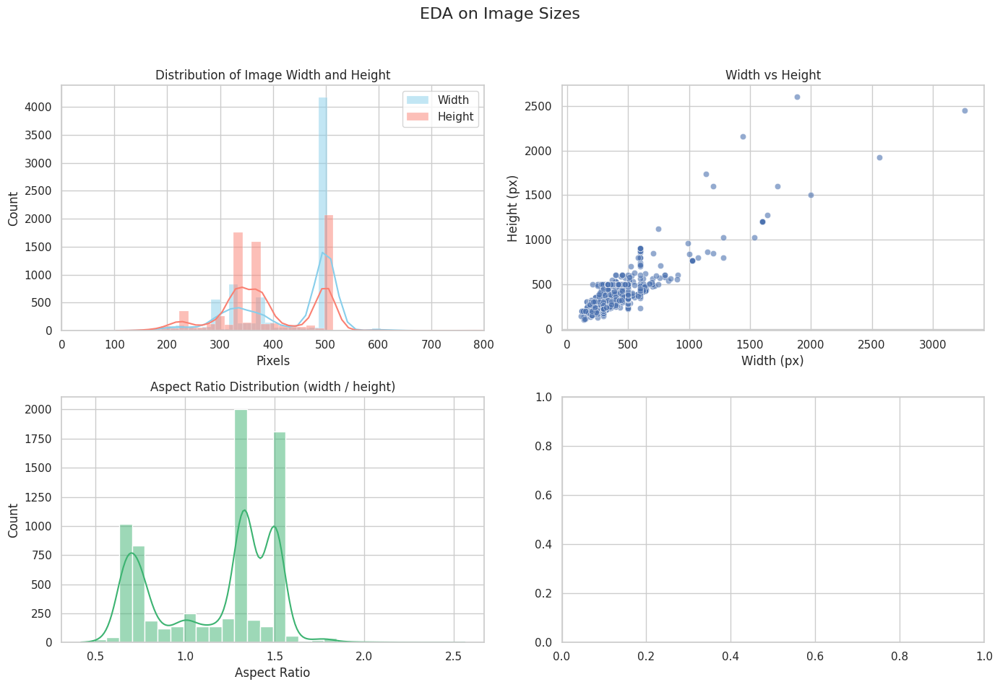

Descriptive statistics of image dimensions:


,width,height,aspect_ratio
count,7390.000000,7390.000000,7390.000000
mean,436.745196,390.913667,1.171843
std,115.877300,109.586324,0.328554
min,114.000000,103.000000,0.420000
25%,335.000000,333.000000,0.750000
50%,500.000000,375.000000,1.330000
75%,500.000000,500.000000,1.490000
max,3264.000000,2606.000000,2.560000


In [ ]:
run_eda_on_image_sizes("ipcv-assignment-2/dataset/images")

### EDA on Image Colors

Analyzing colors: 100%|██████████| 7390/7390 [00:36<00:00, 202.25it/s]


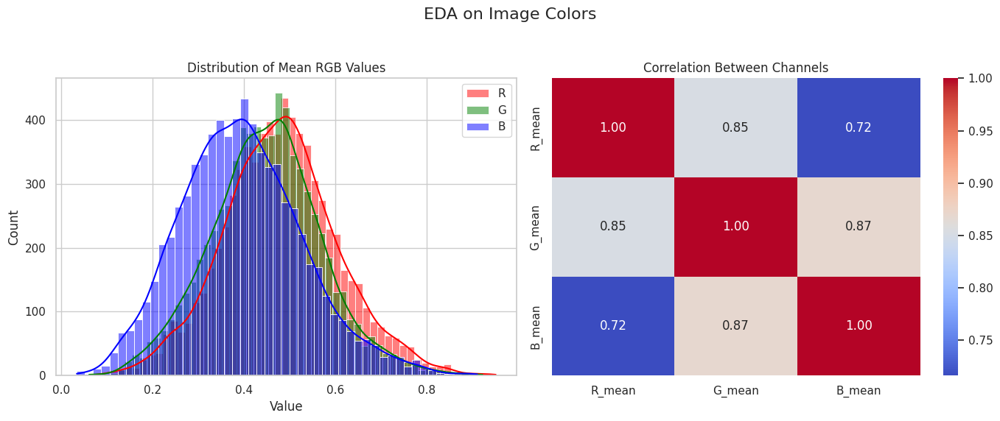

Descriptive statistics of RGB mean values:


,R_mean,G_mean,B_mean
count,7390.000000,7390.000000,7390.000000
mean,0.481079,0.449165,0.395695
std,0.125737,0.121122,0.133435
min,0.076688,0.061725,0.034835
25%,0.398667,0.371315,0.302539
50%,0.479933,0.450264,0.389839
75%,0.558516,0.524436,0.479487
max,0.951291,0.922368,0.910774


In [ ]:
run_eda_on_colors("ipcv-assignment-2/dataset/images")

An additional EDA was performed on the color distribution of the images, but **only on the training dataset**.  
This is because the **mean and standard deviation** values computed from the training images are later used in data augmentation and normalization processes.  
Using information from the validation or test sets at this stage would lead to **data leakage**, as it would expose the model to statistics derived from unseen data, compromising the integrity of the evaluation.


Analyzing colors: 100%|██████████| 3669/3669 [00:18<00:00, 199.09it/s]


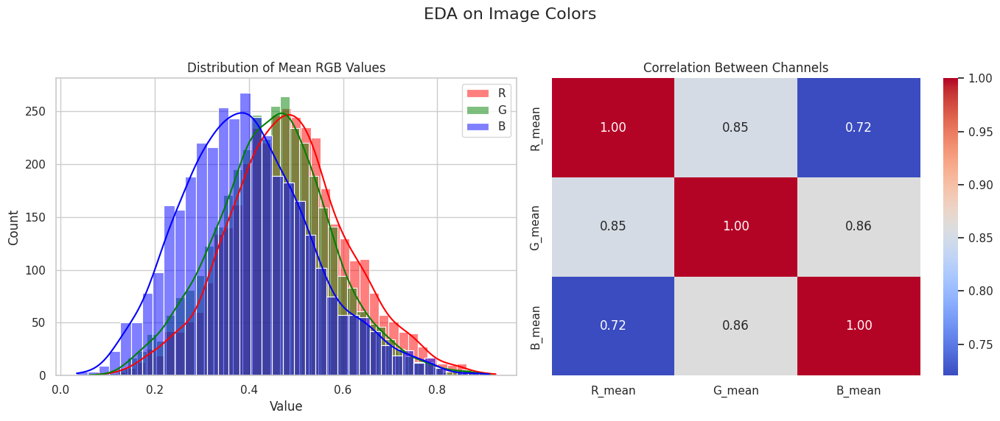

Descriptive statistics of RGB mean values:


,R_mean,G_mean,B_mean
count,3669.000000,3669.000000,3669.000000
mean,0.484464,0.452907,0.395849
std,0.128568,0.124859,0.137331
min,0.076688,0.061725,0.034835
25%,0.400130,0.373063,0.298599
50%,0.481522,0.453864,0.388060
75%,0.562597,0.530735,0.481140
max,0.923839,0.912641,0.910774


In [ ]:
run_eda_on_colors(train_dataset)

### EDA on Dataset Splits

#### Training Dataset

Total number of images: 3669
Number of classes: 37


Extracting labels: 100%|██████████| 3669/3669 [00:10<00:00, 341.05it/s]


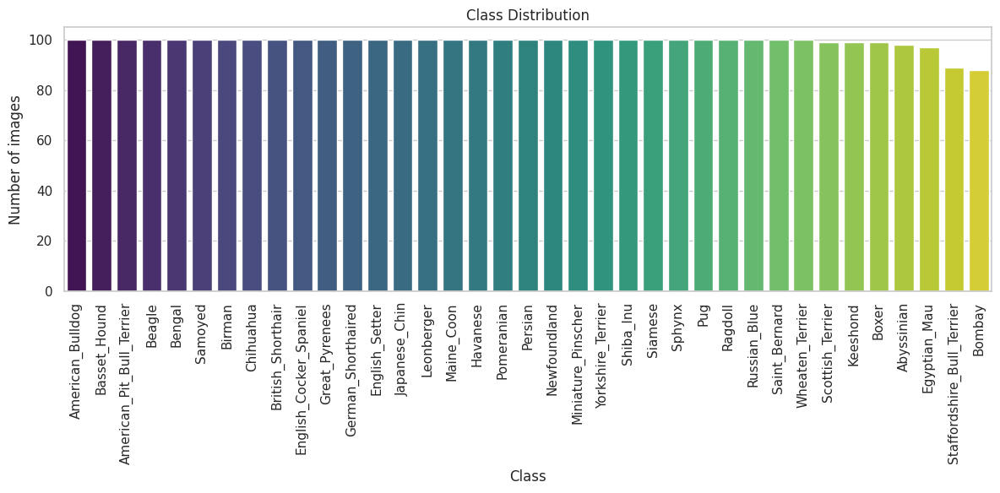

In [ ]:
run_eda(train_dataset, class_names)

#### Validation Dataset

Total number of images: 1834
Number of classes: 37


Extracting labels: 100%|██████████| 1834/1834 [00:04<00:00, 394.56it/s]


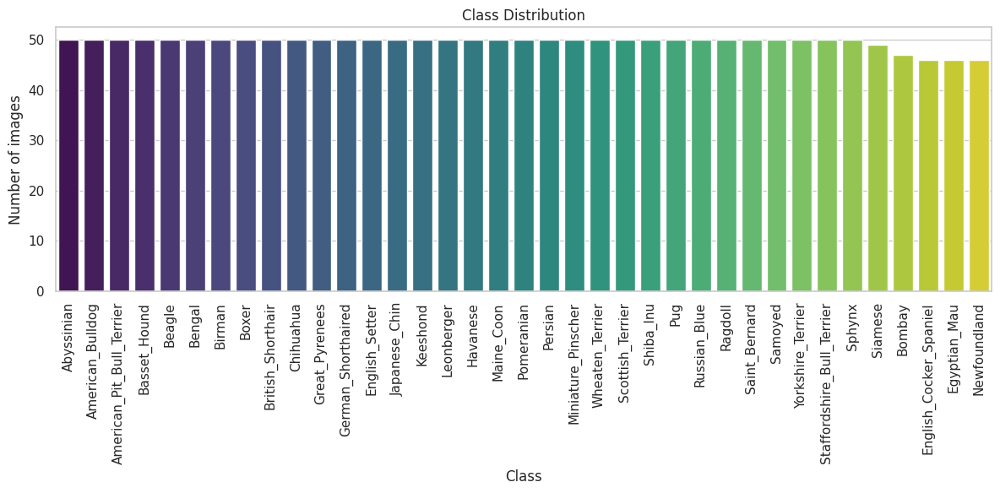

In [ ]:
run_eda(val_dataset, class_names)

#### Test Dataset

Total number of images: 1846
Number of classes: 37


Extracting labels: 100%|██████████| 1846/1846 [00:05<00:00, 365.79it/s]


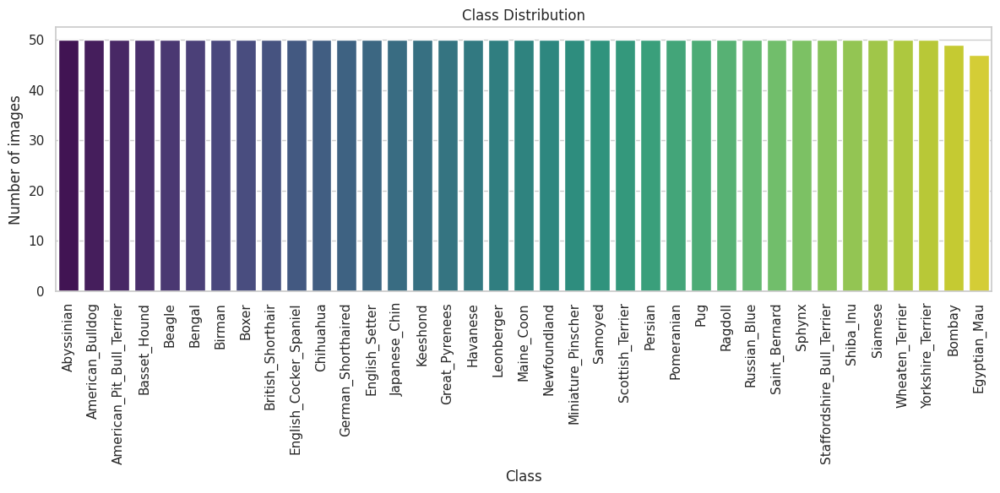

In [ ]:
run_eda(test_dataset, class_names)

## Data Augmentation

For this task, the **quality of data augmentation** turned out to be fundamental in achieving good generalization. Given the variability in the dataset (e.g., background, lighting, and pose changes), applying diverse and strong augmentations helps the model become more robust and prevents overfitting.

**Explanation of the augmentations**:
- `RandomResizedCrop`: randomly crops and resizes the image to simulate zoom-in and zoom-out.
- `RandomHorizontalFlip`: horizontally flips the image to simulate left-right orientation variation.
- `RandomRotation`: rotates the image randomly up to 30 degrees.
- `ColorJitter`: randomly alters brightness, contrast, saturation, and hue for color diversity.
- `RandomAffine`: applies small translations to simulate shifting in the frame.
- `Normalize`: standardizes pixel values using precomputed dataset mean and std.
- `RandomErasing`: simulates occlusion by removing a random region of the image (also known as Cutout).

Additionally, **MixUp** was implemented to further improve generalization. MixUp combines two images and their labels using a linear interpolation, forcing the model to learn smoother decision boundaries. Since PyTorch does not provide a native implementation of MixUp, it was manually added to the **training loop**.


In [ ]:
# Taken from previus EDA
mean_images = [0.484,	0.453,	0.396]
std_images = [0.129,	0.125,	0.137]

train_transform = transforms.Compose([
      transforms.RandomResizedCrop(128, scale=(0.8, 1.2)),
      transforms.RandomHorizontalFlip(p=0.5),
      transforms.RandomRotation(30),
      transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
      transforms.RandomAffine(0, translate=(0.1, 0.1)),
      transforms.ToTensor(),
      transforms.Normalize(mean_images, std_images),
      transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random')  # Cutout
    ])

# Equal for Test
val_transform = transforms.Compose([
      transforms.Resize((128, 128)),
      transforms.ToTensor(),
      transforms.Normalize(mean_images, std_images)
    ])

### Graphical visualization of Transformations

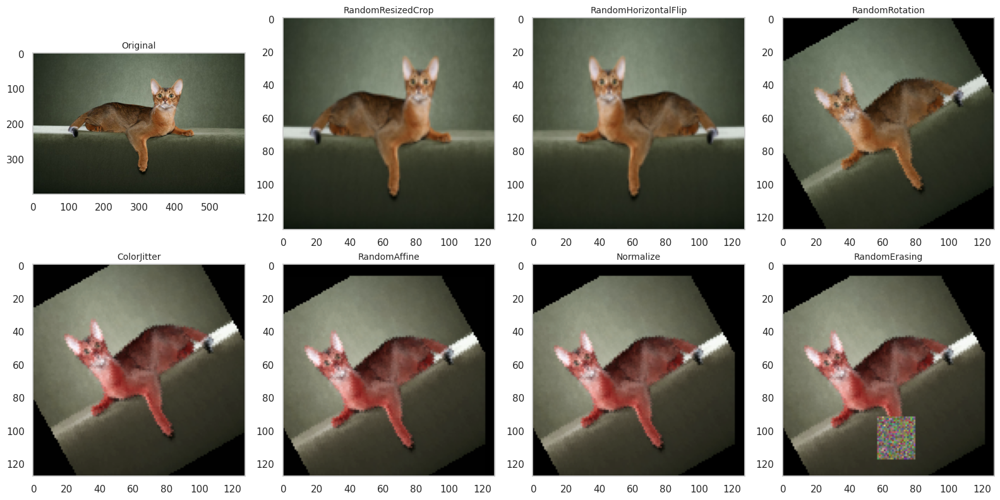

In [ ]:
visualize_transforms("ipcv-assignment-2/dataset/images/Abyssinian_1.jpg", mean_images, std_images)

### Graphical visualization of MixUp

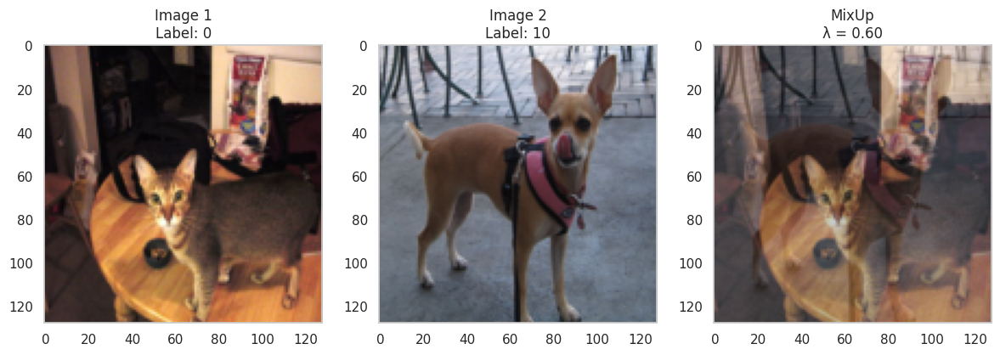

Mixed Label:
[0.6 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.4 0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0. ]


In [ ]:
img1, label1 = train_dataset[0]
img2, label2 = train_dataset[1000]

visualize_mixup(img1, img2, label1, label2, lam = 0.6, num_classes=37)

## Model

To tackle the Oxford-IIIT Pet classification task, we designed a custom convolutional neural network named **PetNet**. Inspired by common deep learning design principles, PetNet is a lightweight yet powerful architecture that progressively extracts hierarchical features using convolutional blocks, followed by global average pooling and a final classification layer. The model balances depth and efficiency, making it well-suited for medium-sized datasets. In combination with strong data augmentation, PetNet consistently achieves high accuracy and generalization performance.

### HyperParameters for Training
After numerous attempts and hyperparameter tuning, these are the hyperparameters that provide the model with the best performance.

In [ ]:
hyperparameters = {
    #Training
    "batch_size": 64,
    "num_epochs": 150,

    #Normalization
    "label_smoothing": 0.1,
    "weight_decay": 1e-4,

    #Data Augmentation
    "mix_up": 0.4,
    "mixup_start_epoch": 10,

    #Initial lr
    "lr": 0.001,

    #Learnig Rate Scheduler
    "scheduler": {
                "max_lr" : 5e-3,
                "pct_start" : 0.3,
                "anneal_strategy" : "cos",
                "div_factor" : 20,
                }

}

### DataLoader

Definition of data loader with the **augmented** data.

In [ ]:
# Dataset: Here there are the trasnformations!
train_dataset = OxfordPetDataset(split="train", transform=train_transform)
val_dataset = OxfordPetDataset(split="val", transform=val_transform)
test_dataset = OxfordPetDataset(split="test", transform=val_transform)

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=hyperparameters['batch_size'], shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=hyperparameters['batch_size'], shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=hyperparameters['batch_size'], shuffle=False, num_workers=4)

print(f"Training Dataset has {len(train_dataset)} elements")
print(f"Validation Dataset has {len(val_dataset)} elements")
print(f"Test Dataset has {len(test_dataset)} elements")

Training Dataset has 3669 elements
Validation Dataset has 1834 elements
Test Dataset has 1846 elements


### ConvBlock

The `ConvBlock` class defines a convolutional block commonly used in convolutional neural networks.  
It consists of **two convolutional layers**, each followed by **batch normalization** and a **ReLU activation**.
Its **modular design** simplifies the ablation study conducted afterwards.

#### Components:

- `in_channels`, `out_channels`: number of input and output channels for the convolutions.
- `downsample` (default `False`): if `True`, the first convolution is performed with a stride of 2, effectively halving the spatial resolution.
- `use_batchnorm` (default `True`): if `True`, applies `BatchNorm2d` after each convolution to improve training stability.

#### Block Structure:

1. **First Conv Layer**:
   - 3×3 convolution (with optional stride 2 if `downsample=True`)
   - Optional batch normalization
   - ReLU activation

2. **Second Conv Layer**:
   - 3×3 convolution (stride 1)
   - Optional batch normalization
   - ReLU activation

The two layers are wrapped inside a `nn.Sequential`, stored as `self.block`.

This modular design allows the block to be reused with different configurations and easily integrated into deeper networks.


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False, use_batchnorm=True):
        super().__init__()
        stride = 2 if downsample else 1

        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

### PetNet

The `PetNet` class defines a lightweight, modular convolutional neural network. It is composed of an initial convolutional layer, a configurable stack of convolutional blocks, a global pooling layer, and a final fully connected layer for classification.

#### Parameters:

- `num_classes`: number of output classes for the classification task.
- `num_blocks` (default `4`): number of convolutional blocks (`ConvBlock`) used in the network.
- `pool_type` (default `"avg"`): type of global pooling used before the final layer. Can be `"avg"` (AdaptiveAvgPool2d) or `"max"` (AdaptiveMaxPool2d).
- `use_batchnorm` (default `True`): whether to include `BatchNorm2d` layers throughout the network.


**Layers Breakdown**:
1. **Initial Layer**:
   - 3×3 convolution (from 3 to 32 channels)
   - Optional batch normalization
   - ReLU activation

2. **Convolutional Blocks**:
   - A sequence of `num_blocks` `ConvBlock` instances
   - Each block doubles the number of channels and downsamples the input using stride 2
   - Channel progression: `32 -> 64 -> 128 -> 256 -> 512` (up to the number of blocks)

3. **Global Pooling**:
   - Either `AdaptiveAvgPool2d(1)` or `AdaptiveMaxPool2d(1)` to reduce spatial dimensions to 1×1

4. **Fully Connected Layer**:
   - A `Linear` layer mapping from the final feature dimension to `num_classes`

In [ ]:
class PetNet(nn.Module):
    def __init__(self, num_classes, num_blocks=4, pool_type="avg", use_batchnorm=True):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        channels = [32, 64, 128, 256, 512]
        layers = []
        for i in range(num_blocks):
            in_ch = channels[i]
            out_ch = channels[i + 1]
            layers.append(ConvBlock(in_ch, out_ch, downsample=True, use_batchnorm=use_batchnorm))
        self.blocks = nn.Sequential(*layers)

        self.gap = nn.AdaptiveAvgPool2d(1) if pool_type == "avg" else nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Linear(channels[num_blocks], num_classes)

    def forward(self, x):
        x = self.initial(x)
        x = self.blocks(x)
        x = self.gap(x)         # (N, C, 1, 1)
        x = torch.flatten(x, 1) # (N, C)
        x = self.fc(x)
        return x

In [ ]:
model_baseline = PetNet(num_classes=train_dataset.get_num_classes(),
                        num_blocks=4,
                        pool_type="avg",
                        use_batchnorm=True
                        ).to(device)

In [ ]:
print(model_baseline)
print("\nParameters and FLOPs:\n")
baseline_stat = model_stats(model_baseline, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

## Training

### Training and Validation Pipeline

Here we provide a summary of the functions that define the core training and validation routines used to train the model. The actual code implementations can be found in the [Utility Functions\Training and Validation](https://colab.research.google.com/drive/1BqR8Gcdrd_uXRPoo1D9CyZWzyRYChMS-#scrollTo=yH2DHJf6BIHs&line=1&uniqifier=1) section.

- **`reset_weights(model)`**: Resets all the trainable parameters of a given model to their initial state. Useful for reinitializing models before retraining.
  
- **`accuracy(output, target)`**: Computes the classification accuracy by comparing predicted labels with true labels.

- **`train_epoch(...)`**: Runs one epoch of training with support for MixUp data augmentation. It computes the loss and accuracy ans applies backpropagation.

- **`val_epoch(...)`**: Evaluates the model on a validation set, computing average loss and accuracy without modifying model parameters.

- **`mixup_data(...)`**: Implements the MixUp strategy, which generates new training examples by linearly interpolating pairs of examples and their labels.

- **`mixup_criterion(...)`**: Combines the loss contributions from both mixed labels in MixUp training, weighted by the mixing coefficient `λ`.

This pipeline supports both standard and MixUp-based training and enables smooth integration with learning rate scheduler.




### Loss, Optimizer and Learning Rate Scheduler

In this cell, the **CrossEntropyLoss** function is defined with *label smoothing* to improve generalization and reduce overconfidence in class predictions.  

The **AdamW** optimizer is used instead of the standard Adam, as it decouples weight decay from the gradient updates, providing better regularization and more stable convergence.

The **OneCycleLR** learning rate scheduler is then configured based on the number of training steps per epoch and the total number of epochs.  
This scheduler cyclically increases and then decreases the learning rate, following the *1-cycle policy* that often leads to faster and more robust convergence.

As specified in the **official PyTorch documentation**, the `scheduler.step()` method must be called **after every batch**, not after every epoch.  
This behavior is correctly handled within our custom training function, ensuring that the learning rate is updated dynamically throughout the training process.


In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_baseline.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

### Training Loop

In [ ]:
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_baseline,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up=hyperparameters['mix_up'],
    mixup_start_epoch=hyperparameters['mixup_start_epoch'],
    device=device,
    save_path="model_baseline.pth",
    history_prefix="model_baseline"
)

100%|██████████| 58/58 [00:24<00:00,  2.41it/s]


Epoch 1/150
  Train loss: 3.5215, accuracy: 0.0597
  Val   loss: 3.6648, accuracy: 0.0480
  Learning rate: 0.000256


100%|██████████| 58/58 [00:23<00:00,  2.52it/s]


Epoch 2/150
  Train loss: 3.3858, accuracy: 0.1006
  Val   loss: 3.4711, accuracy: 0.0878
  Learning rate: 0.000273


100%|██████████| 58/58 [00:23<00:00,  2.45it/s]


...

Epoch 148/150
  Train loss: 1.4024, accuracy: 0.8237
  Val   loss: 1.7839, accuracy: 0.6761
  Learning rate: 0.000004


100%|██████████| 58/58 [00:22<00:00,  2.57it/s]


Epoch 149/150
  Train loss: 1.3927, accuracy: 0.8439
  Val   loss: 1.7835, accuracy: 0.6783
  Learning rate: 0.000001


100%|██████████| 58/58 [00:21<00:00,  2.74it/s]


Epoch 150/150
  Train loss: 1.4824, accuracy: 0.8084
  Val   loss: 1.7648, accuracy: 0.6778
  Learning rate: 0.000000
Training complete. History saved.


### Training History

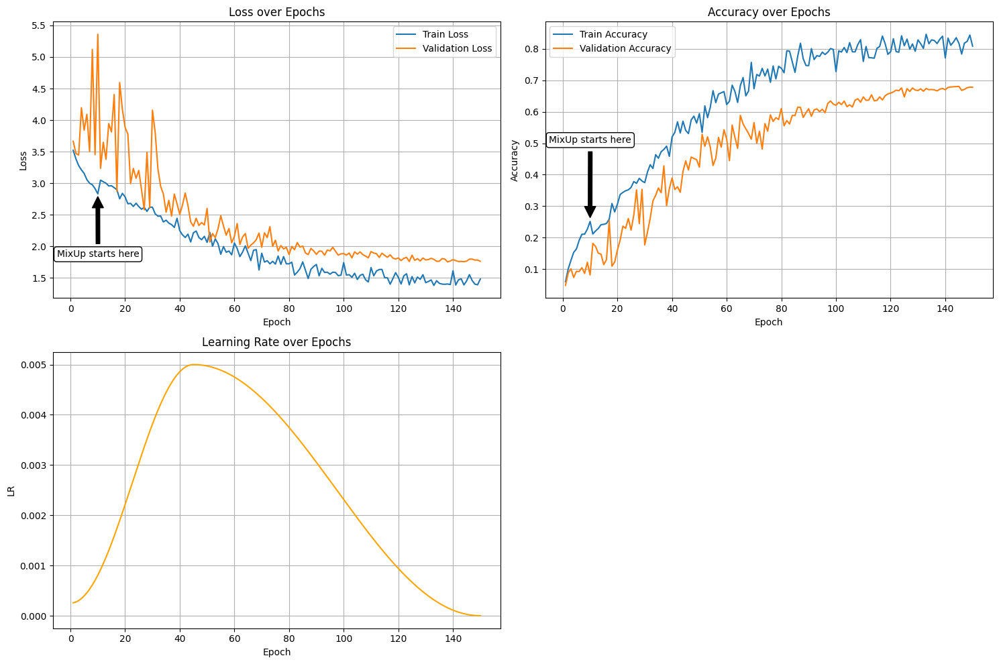

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates)

## Testing

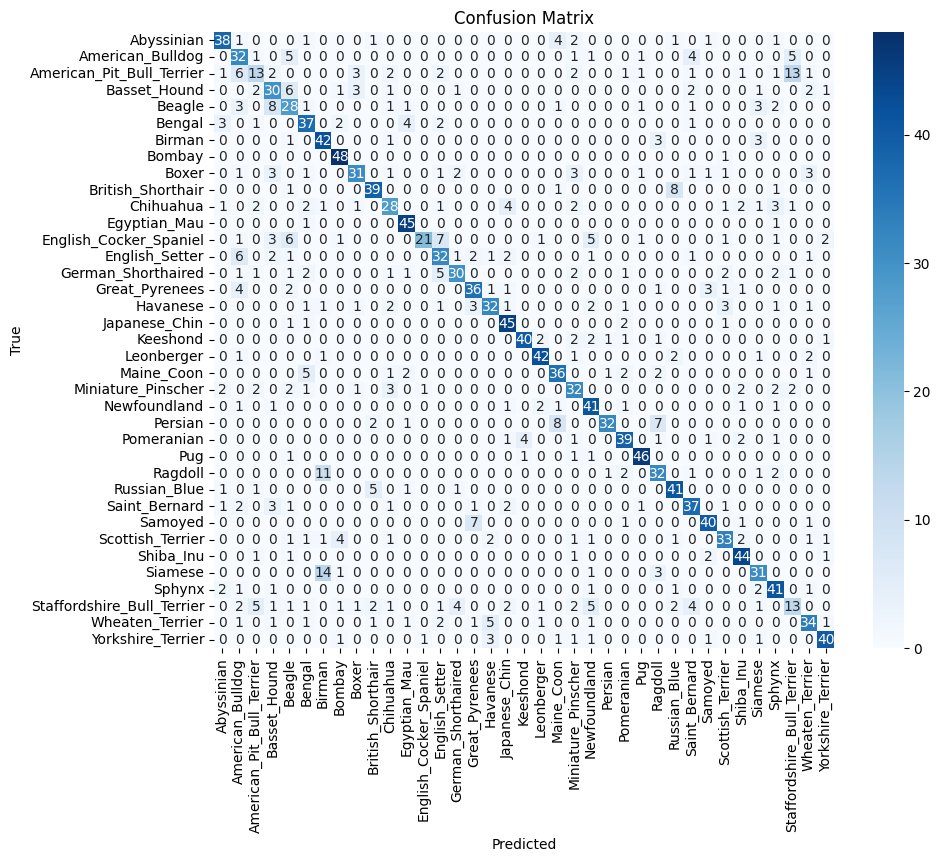

***************************
* Test Accuracy: 0.7048 *
***************************


In [ ]:
# Load the best model state
best_model = PetNet(num_classes=test_dataset.get_num_classes()).to(device)
best_model.load_state_dict(torch.load("model_baseline.pth"))

test_acc = test_epoch(best_model, test_loader, class_names)

## Ablation Study

An ablation study is a systematic analysis used to understand the contribution of individual components or design choices in a machine learning model. By selectively removing or altering parts of the model or training pipeline (such as data augmentation, architectural blocks, or regularization techniques) we can observe how performance is affected. This helps to identify which elements are critical for the model’s success and which may be unnecessary or redundant. Ablation studies are particularly useful for justifying design decisions and improving model efficiency, as they provide empirical evidence of what works and why.


| Part Affected | Name | Note  |
|----|------|------|
| None| baseline | PetNet + Data Augmentation|
| Nr of ConvBlocks| ablation_1| Depth reduced by one ConvBlock|
|Label Smoothing | ablation_2 | No Label Smoothing|
| BatchNorm | ablation_3        | BN removed    |
|Global Average Pooling         | ablation_4      | GAP becomes MaxPool
|Data Augmentation | ablation_5 | MixUp removed|
|Data Augmentation | ablation_6 | No Data Augmentation at all|
|Learning Rate Scheduler | ablation_7 | OneCycle LR removed|


In [ ]:
#Some Variables for final Comparison

#Initialized lists with baseline_model values
baseline_stat['test_accuracy'] = test_acc
stats = [baseline_stat]

train_accuracies_list = [train_accuracies]
val_accuracies_list = [val_accuracies]
train_losses_list = [train_losses]
val_losses_list = [val_losses]

### Number of ConvBlocks

As part of the ablation study, we evaluated the impact of model depth by removing one convolutional block from the original PetNet architecture. This modified version of the network, with a reduced number of parameters and layers, was retrained from scratch under the same training conditions. After training, we re-evaluated its performance on the test sets to compare it against the full model. This allowed us to assess how much the removed block contributed to the model’s learning capacity and final accuracy.

In [ ]:
model_ablation_1 = PetNet(num_classes=train_dataset.get_num_classes(),
                                    num_blocks=3,  # <--- Here the Ablation
                                    pool_type="avg",
                                    use_batchnorm=True).to(device)

print(model_ablation_1)
print("\nParameters and FLOPs:\n")
ablation_1_stat = model_stats(model_ablation_1, (1, 3, 128, 128))


PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_1.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

#Start Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up=hyperparameters['mix_up'],
    mixup_start_epoch=hyperparameters['mixup_start_epoch'],
    device=device,
    save_path="model_ablation_1.pth",
    history_prefix="model_ablation_1"
)

100%|██████████| 58/58 [00:26<00:00,  2.22it/s]


Epoch 1/150
  Train loss: 3.5473, accuracy: 0.0534
  Val   loss: 3.5803, accuracy: 0.0545
  Learning rate: 0.000256


100%|██████████| 58/58 [00:21<00:00,  2.75it/s]


Epoch 2/150
  Train loss: 3.4457, accuracy: 0.0867
  Val   loss: 3.5012, accuracy: 0.0736
  Learning rate: 0.000273


100%|██████████| 58/58 [00:21<00:00,  2.72it/s]


...

Epoch 148/150
  Train loss: 1.5308, accuracy: 0.8059
  Val   loss: 1.9176, accuracy: 0.6091
  Learning rate: 0.000004


100%|██████████| 58/58 [00:23<00:00,  2.49it/s]


Epoch 149/150
  Train loss: 1.5080, accuracy: 0.8227
  Val   loss: 1.9166, accuracy: 0.6069
  Learning rate: 0.000001


100%|██████████| 58/58 [00:21<00:00,  2.76it/s]


Epoch 150/150
  Train loss: 1.6103, accuracy: 0.7844
  Val   loss: 1.9133, accuracy: 0.6080
  Learning rate: 0.000000
Training complete. History saved.


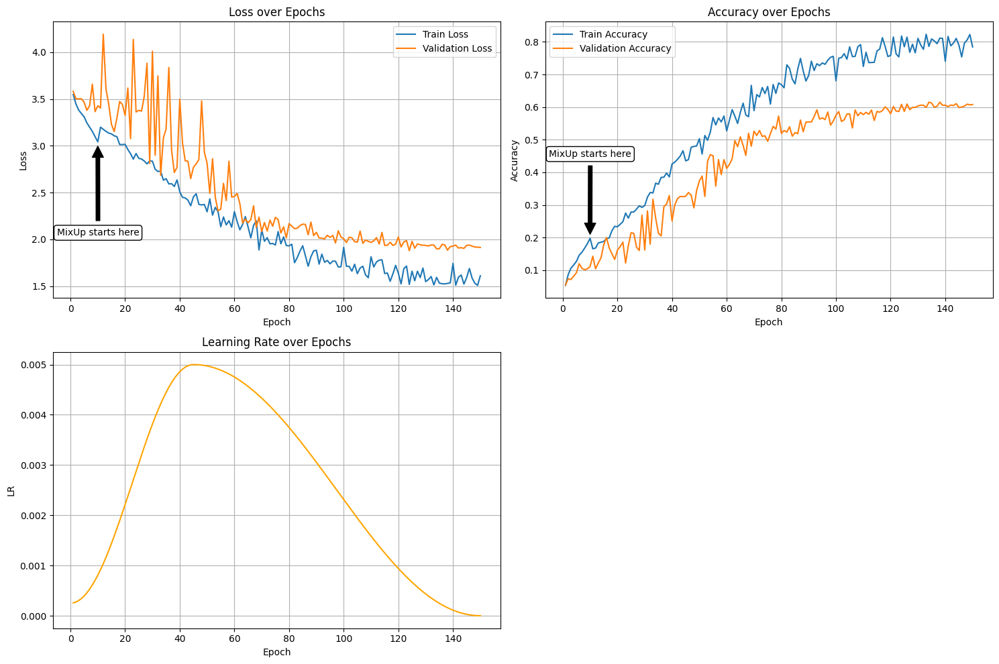

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates)

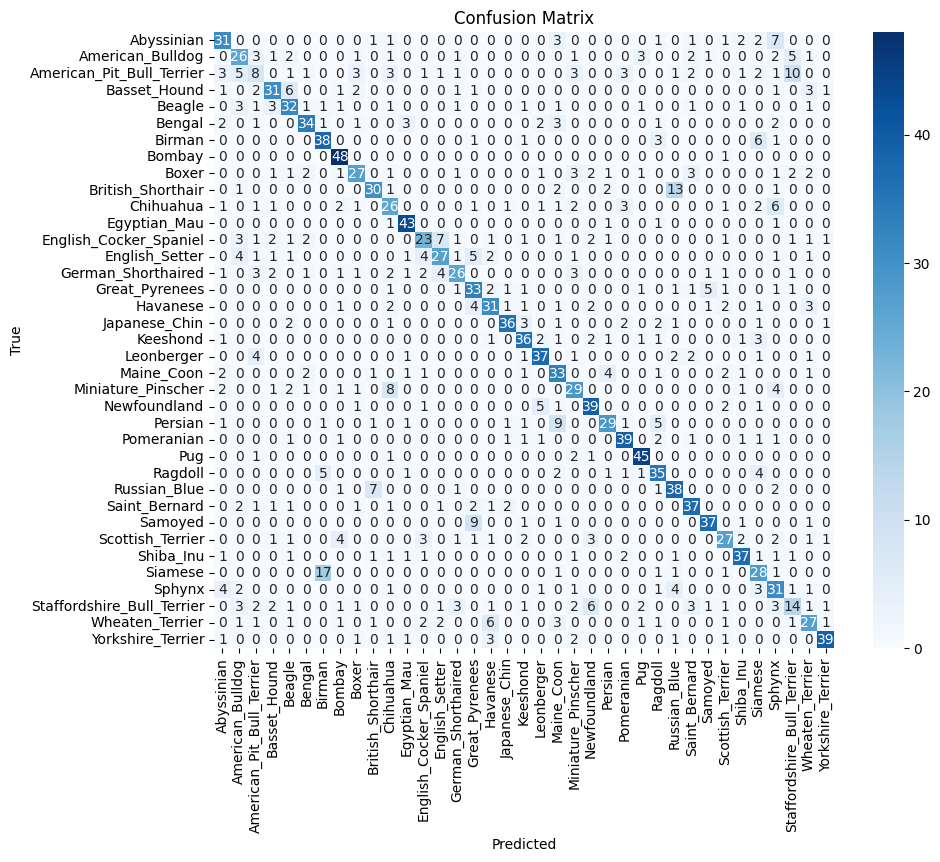

***************************
* Test Accuracy: 0.6430 *
***************************


In [ ]:
best_model_ablation_1 = PetNet(num_classes=train_dataset.get_num_classes(),
                                    num_blocks=3,
                                    pool_type="avg",
                                    use_batchnorm=True).to(device)

best_model_ablation_1.load_state_dict(torch.load("model_ablation_1.pth"))

test_acc = test_epoch(best_model_ablation_1, test_loader, class_names)

#Add info to Comparison
ablation_1_stat['test_accuracy'] = test_acc
stats.append(ablation_1_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Label Smoothing

Label smoothing is a regularization technique that slightly adjusts the target labels during training by assigning a small portion of the probability mass to incorrect classes. This helps prevent the model from becoming overly confident in its predictions, thereby improving generalization. In the context of our ablation study, we **removed label smoothing** to evaluate its impact on final accuracy and training stability. By comparing the results to the baseline model, we can observe how this technique influences learning performance and robustness.


In [ ]:
model_ablation_2 = PetNet(num_classes=train_dataset.get_num_classes()).to(device)

print(model_ablation_2)
print("\nParameters and FLOPs:\n")
ablation_2_stat = model_stats(model_ablation_2, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=0 #<--- Here the Ablation
                                )

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_2.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

#Start Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up=hyperparameters['mix_up'],
    mixup_start_epoch=hyperparameters['mixup_start_epoch'],
    device=device,
    save_path="model_ablation_2.pth",
    history_prefix="model_ablation_2"
)

100%|██████████| 58/58 [00:21<00:00,  2.65it/s]


Epoch 1/150
  Train loss: 3.5083, accuracy: 0.0630
  Val   loss: 3.6207, accuracy: 0.0627
  Learning rate: 0.000256


100%|██████████| 58/58 [00:23<00:00,  2.52it/s]


Epoch 2/150
  Train loss: 3.3610, accuracy: 0.0883
  Val   loss: 3.4511, accuracy: 0.0796
  Learning rate: 0.000273


100%|██████████| 58/58 [00:22<00:00,  2.54it/s]


...

Epoch 148/150
  Train loss: 0.9285, accuracy: 0.8208
  Val   loss: 1.4240, accuracy: 0.6456
  Learning rate: 0.000004


100%|██████████| 58/58 [00:23<00:00,  2.51it/s]


Epoch 149/150
  Train loss: 0.9120, accuracy: 0.8362
  Val   loss: 1.4052, accuracy: 0.6429
  Learning rate: 0.000001


100%|██████████| 58/58 [00:22<00:00,  2.54it/s]


Epoch 150/150
  Train loss: 1.0268, accuracy: 0.8030
  Val   loss: 1.3995, accuracy: 0.6445
  Learning rate: 0.000000
Training complete. History saved.


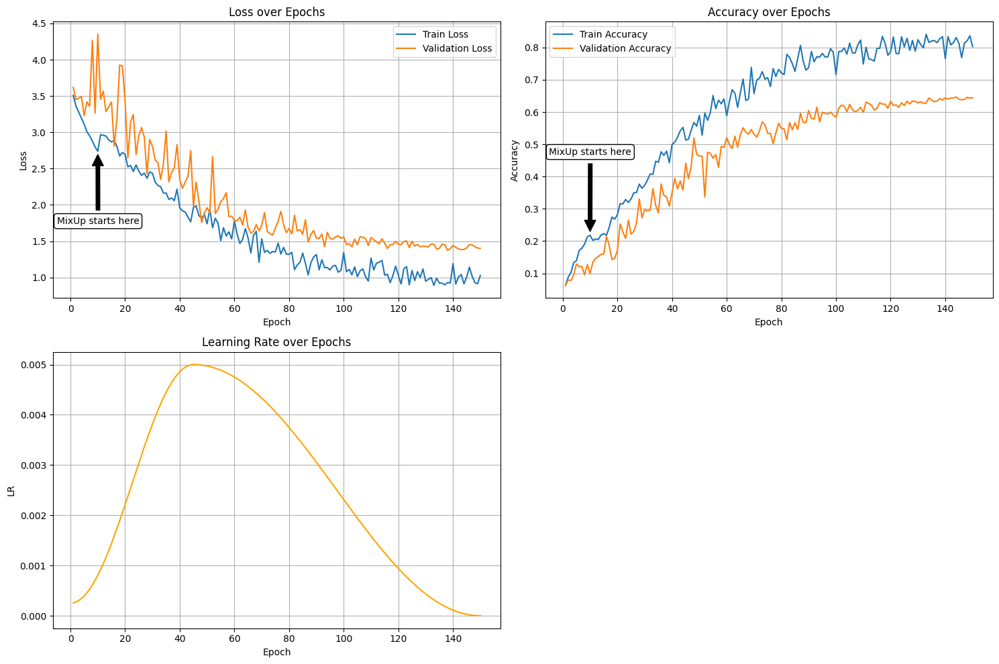

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates)

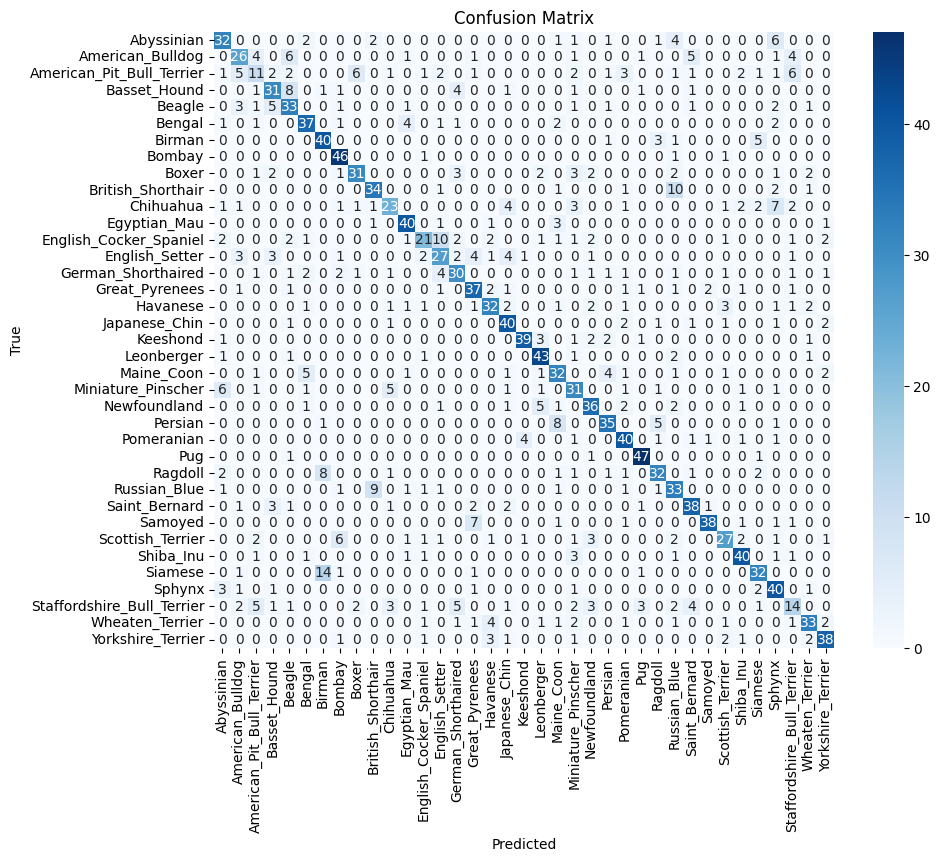

***************************
* Test Accuracy: 0.6712 *
***************************


In [ ]:
best_model_ablation_2 = PetNet(num_classes=test_dataset.get_num_classes()).to(device)
best_model_ablation_2.load_state_dict(torch.load("model_ablation_2.pth"))

test_acc = test_epoch(best_model_ablation_2, test_loader, class_names)

#Add info to Comparison
ablation_2_stat['test_accuracy'] = test_acc
stats.append(ablation_2_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Batch Normalization

Batch Normalization is a widely used technique that normalizes the activations of each layer to stabilize and accelerate training. It helps mitigate internal covariate shift, allowing for higher learning rates and improved convergence. In our ablation study, we **removed Batch Normalization layers** from the model to assess their contribution. The results show that removing Batch Normalization significantly degrades performance, highlighting its crucial role in enabling effective and stable training.


In [ ]:
model_ablation_3 = PetNet(num_classes=train_dataset.get_num_classes(),
                                    num_blocks=4,
                                    pool_type="avg",
                                    use_batchnorm=False # <--- Here the Ablation
                          ).to(device)

print(model_ablation_3)
print("\nParameters and FLOPs:\n")
ablation_3_stat = model_stats(model_ablation_3, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (3): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (3): ReLU(inplace=True)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding

In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_3.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

#Start Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up=hyperparameters['mix_up'],
    mixup_start_epoch=hyperparameters['mixup_start_epoch'],
    device=device,
    save_path="model_ablation_3.pth",
    history_prefix="model_ablation_3"
)

100%|██████████| 58/58 [00:21<00:00,  2.72it/s]


Epoch 1/150
  Train loss: 3.6114, accuracy: 0.0253
  Val   loss: 3.6114, accuracy: 0.0267
  Learning rate: 0.000256


100%|██████████| 58/58 [00:21<00:00,  2.65it/s]


Epoch 2/150
  Train loss: 3.6113, accuracy: 0.0240
  Val   loss: 3.6112, accuracy: 0.0256
  Learning rate: 0.000273


100%|██████████| 58/58 [00:23<00:00,  2.49it/s]


...

Epoch 148/150
  Train loss: 2.1588, accuracy: 0.5817
  Val   loss: 2.8061, accuracy: 0.3566
  Learning rate: 0.000004


100%|██████████| 58/58 [00:22<00:00,  2.62it/s]


Epoch 149/150
  Train loss: 2.0982, accuracy: 0.6021
  Val   loss: 2.8012, accuracy: 0.3561
  Learning rate: 0.000001


100%|██████████| 58/58 [00:21<00:00,  2.74it/s]


Epoch 150/150
  Train loss: 2.2106, accuracy: 0.5706
  Val   loss: 2.8024, accuracy: 0.3555
  Learning rate: 0.000000
Training complete. History saved.


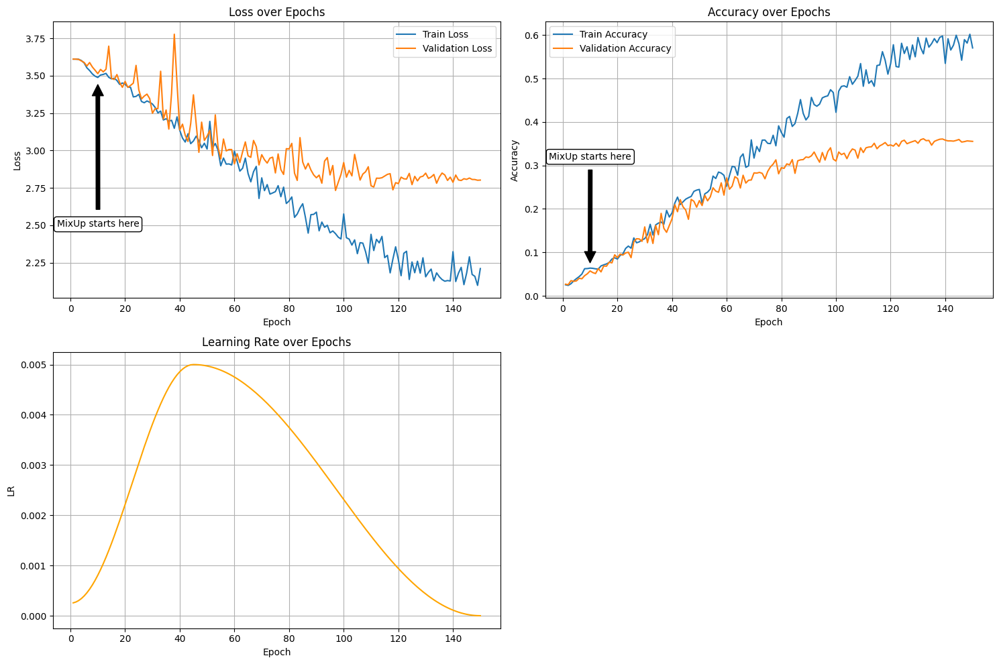

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates)

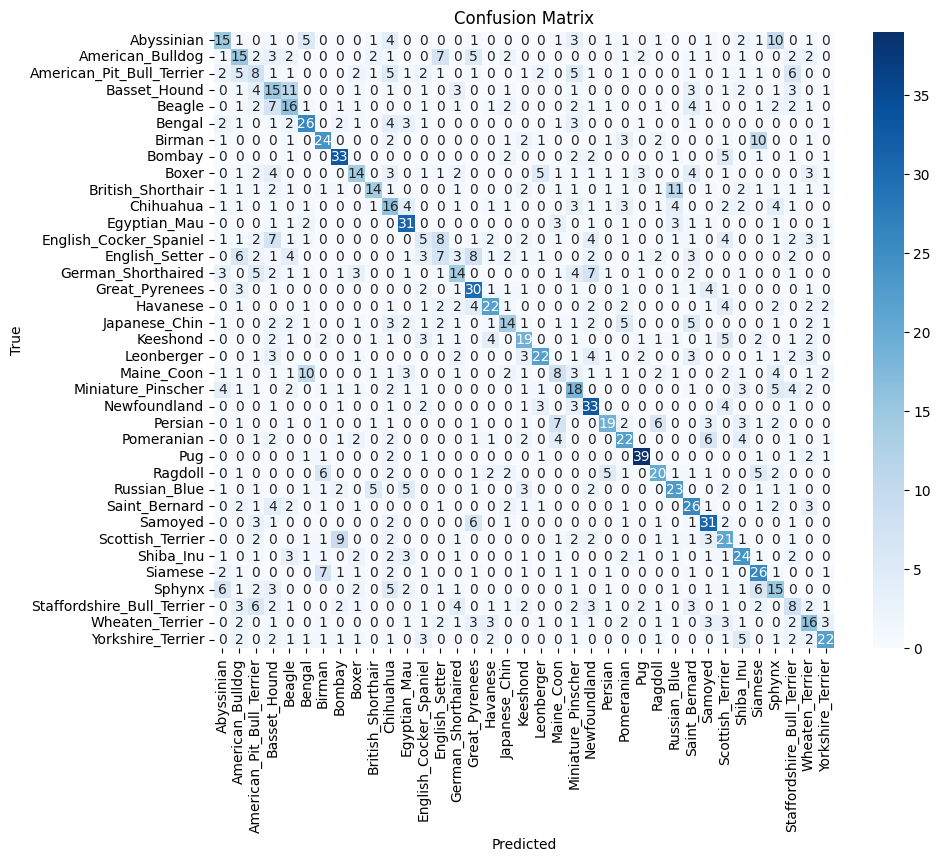

***************************
* Test Accuracy: 0.3960 *
***************************


In [ ]:
best_model_ablation_3 = PetNet(num_classes=train_dataset.get_num_classes(),
                                    num_blocks=4,
                                    pool_type="avg",
                                    use_batchnorm=False).to(device)
best_model_ablation_3.load_state_dict(torch.load("model_ablation_3.pth"))

test_acc = test_epoch(best_model_ablation_3, test_loader, class_names)

#Add info to Comparison
ablation_3_stat['test_accuracy'] = test_acc
stats.append(ablation_3_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Global Average Pooling

Global Average Pooling (GAP) is widely used in convolutional neural networks to reduce the spatial dimensions of feature maps before the final classification layer. It offers an efficient way to summarize feature responses while minimizing the number of parameters and reducing the risk of overfitting. In our ablation study, we replaced GAP with a Max Pooling operation. This change led to a drop in performance, suggesting that GAP is more effective than Max Pooling at preserving the overall semantic structure of the feature maps for classification tasks.


In [ ]:
model_ablation_4 = PetNet(num_classes=train_dataset.get_num_classes(),
                                    num_blocks=4,
                                    pool_type="max", # <--- Here the Ablation
                                    use_batchnorm=True).to(device)


print(model_ablation_4)
print("\nParameters and FLOPs:\n")
ablation_4_stat = model_stats(model_ablation_4, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_4.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

#Start Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_4,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up=hyperparameters['mix_up'],
    mixup_start_epoch=hyperparameters['mixup_start_epoch'],
    device=device,
    save_path="model_ablation_4.pth",
    history_prefix="model_ablation_4"
)

100%|██████████| 58/58 [00:21<00:00,  2.71it/s]


Epoch 1/150
  Train loss: 3.6694, accuracy: 0.0542
  Val   loss: 3.5808, accuracy: 0.0862
  Learning rate: 0.000256


100%|██████████| 58/58 [00:22<00:00,  2.61it/s]


Epoch 2/150
  Train loss: 3.4032, accuracy: 0.1033
  Val   loss: 3.4759, accuracy: 0.1009
  Learning rate: 0.000273


100%|██████████| 58/58 [00:22<00:00,  2.61it/s]


...

Epoch 148/150
  Train loss: 1.5433, accuracy: 0.8037
  Val   loss: 1.9730, accuracy: 0.6200
  Learning rate: 0.000004


100%|██████████| 58/58 [00:22<00:00,  2.57it/s]


Epoch 149/150
  Train loss: 1.4534, accuracy: 0.8180
  Val   loss: 1.9692, accuracy: 0.6172
  Learning rate: 0.000001


100%|██████████| 58/58 [00:22<00:00,  2.60it/s]


Epoch 150/150
  Train loss: 1.5313, accuracy: 0.8014
  Val   loss: 2.0107, accuracy: 0.6107
  Learning rate: 0.000000
Training complete. History saved.


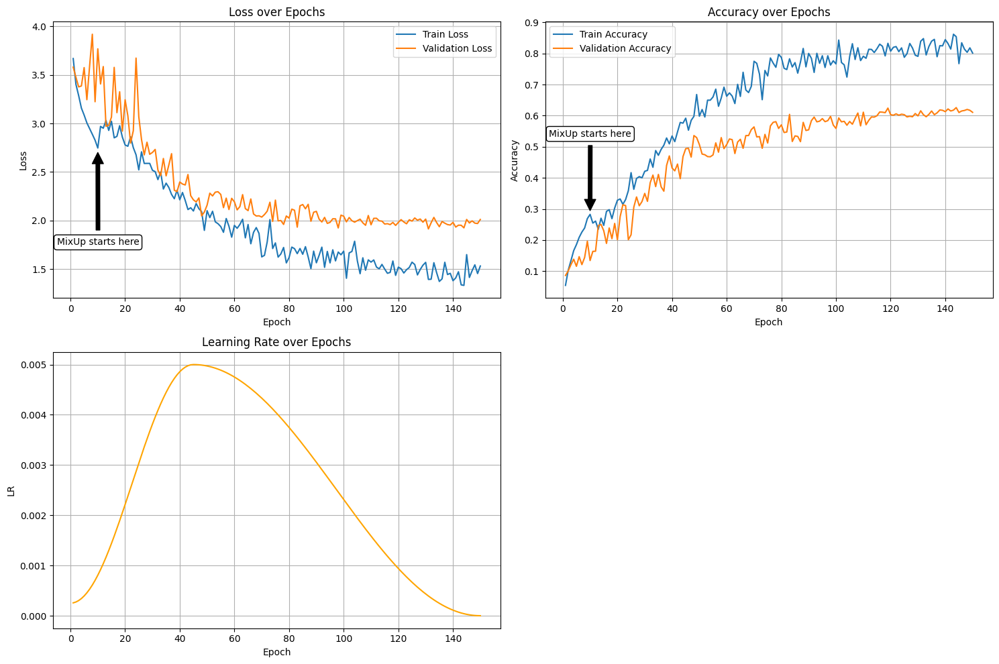

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates)

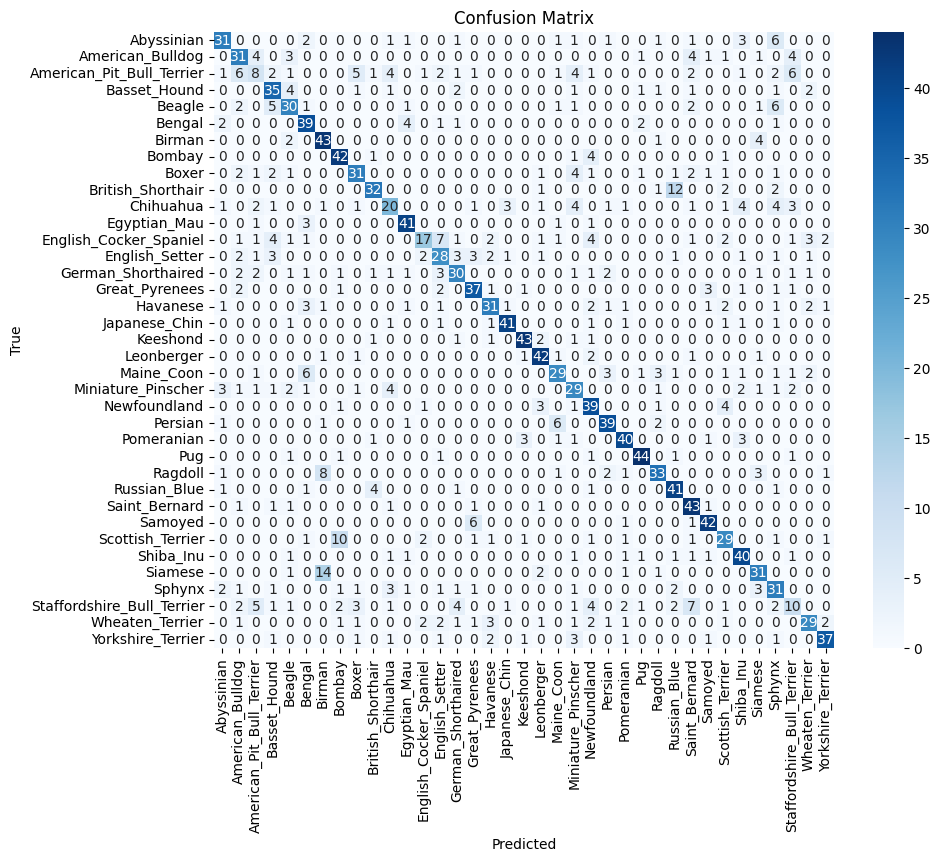

***************************
* Test Accuracy: 0.6706 *
***************************


In [ ]:
best_model_ablation_4 = PetNet(num_classes=train_dataset.get_num_classes(),
                                    num_blocks=4,
                                    pool_type="max",
                                    use_batchnorm=True).to(device)
best_model_ablation_4.load_state_dict(torch.load("model_ablation_4.pth"))

test_acc = test_epoch(best_model_ablation_4, test_loader, class_names)

#Add info to Comparison
ablation_4_stat['test_accuracy'] = test_acc
stats.append(ablation_4_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Data Augmentation (No MixUp)

MixUp is a data augmentation technique that generates new training examples by combining pairs of inputs and their corresponding labels through linear interpolation. It helps improve generalization and model robustness, particularly by reducing overfitting and improving calibration. In our ablation study, we removed MixUp from the training pipeline. This removal resulted in a decrease in model accuracy, confirming that MixUp played a significant role in enhancing the performance and stability of our model.


In [ ]:
model_ablation_5 = PetNet(num_classes=train_dataset.get_num_classes()).to(device)

print(model_ablation_5)
print("\nParameters and FLOPs:\n")
ablation_5_stat = model_stats(model_ablation_5, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_5.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_5,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up= 0, #<--Here the Ablation
    mixup_start_epoch= 0, #<--Here the Ablation
    device=device,
    save_path="model_ablation_5.pth",
    history_prefix="model_ablation_5"
)

100%|██████████| 58/58 [00:25<00:00,  2.31it/s]


Epoch 1/150
  Train loss: 3.5326, accuracy: 0.0632
  Val   loss: 3.8075, accuracy: 0.0600
  Learning rate: 0.000256


100%|██████████| 58/58 [00:25<00:00,  2.30it/s]


Epoch 2/150
  Train loss: 3.3945, accuracy: 0.0919
  Val   loss: 3.5441, accuracy: 0.0763
  Learning rate: 0.000273


100%|██████████| 58/58 [00:24<00:00,  2.34it/s]


...

Epoch 148/150
  Train loss: 0.7537, accuracy: 0.9962
  Val   loss: 1.8608, accuracy: 0.6369
  Learning rate: 0.000004


100%|██████████| 58/58 [00:23<00:00,  2.51it/s]


Epoch 149/150
  Train loss: 0.7506, accuracy: 0.9970
  Val   loss: 1.8630, accuracy: 0.6347
  Learning rate: 0.000001


100%|██████████| 58/58 [00:22<00:00,  2.55it/s]


Epoch 150/150
  Train loss: 0.7496, accuracy: 0.9984
  Val   loss: 1.8624, accuracy: 0.6336
  Learning rate: 0.000000
Training complete. History saved.


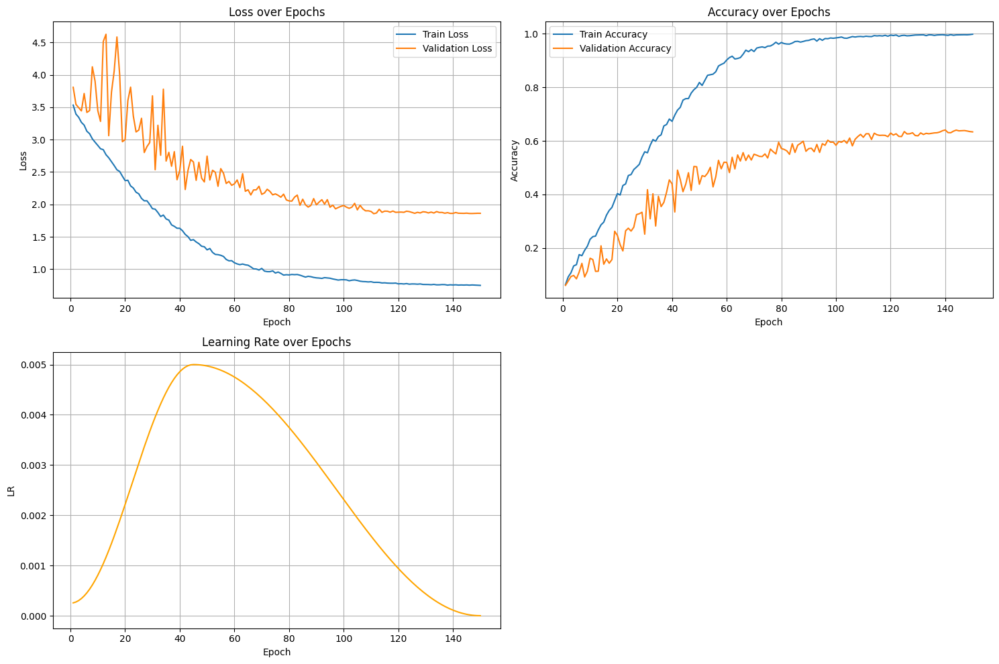

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=False)

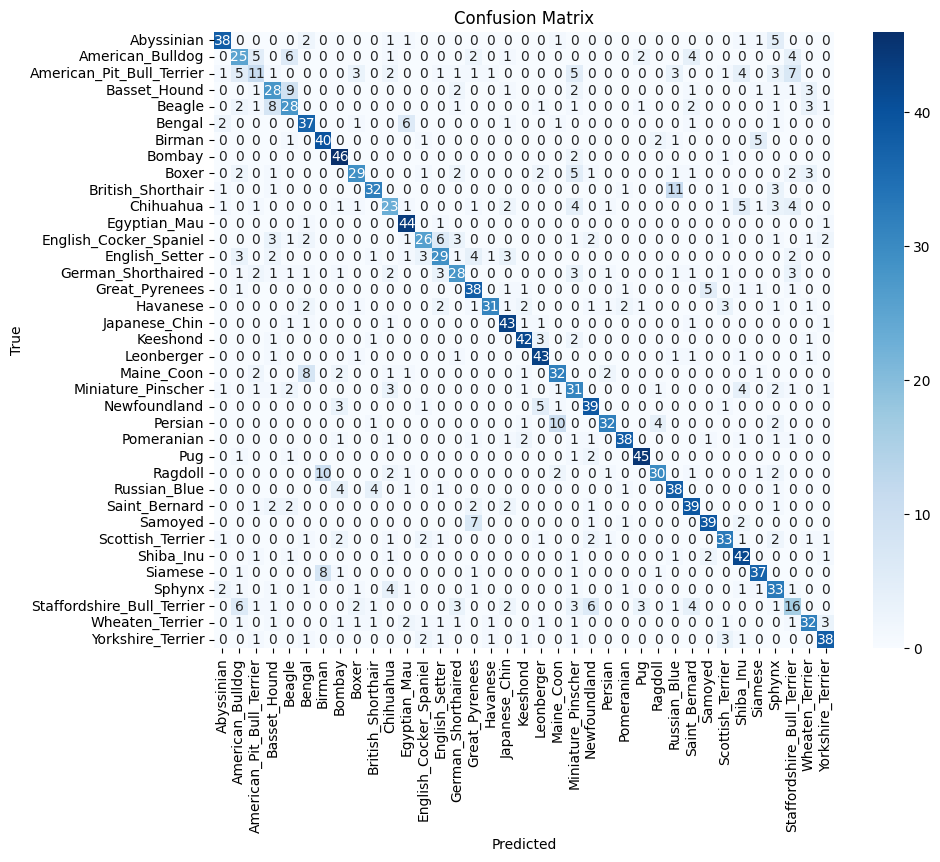

***************************
* Test Accuracy: 0.6798 *
***************************


In [ ]:
best_model_ablation_5 = PetNet(num_classes=test_dataset.get_num_classes()).to(device)
best_model_ablation_5.load_state_dict(torch.load("model_ablation_5.pth"))

test_acc = test_epoch(best_model_ablation_5, test_loader, class_names)

#Add info to Comparison
ablation_5_stat['test_accuracy'] = test_acc
stats.append(ablation_5_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Data Augmentation (Only Resize)

Data augmentation is a crucial technique in deep learning that enhances the diversity of the training dataset by applying transformations such as flipping, rotation, cropping, and color jittering. These augmentations help the model generalize better to unseen data by preventing overfitting. In our ablation study, we removed all data augmentation operations. This led to a significant drop in performance, highlighting a clear overfitted model.

In [ ]:
#Here the Ablation
simple_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Dataset
train_dataset = OxfordPetDataset(split="train", transform=simple_transform)
val_dataset = OxfordPetDataset(split="val", transform=simple_transform)
test_dataset = OxfordPetDataset(split="test", transform=simple_transform)

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=hyperparameters['batch_size'], shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=hyperparameters['batch_size'], shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=hyperparameters['batch_size'], shuffle=False, num_workers=4)

print(f"Training Dataset has {len(train_dataset)} elements")
print(f"Validation Dataset has {len(val_dataset)} elements")
print(f"Test Dataset has {len(test_dataset)} elements")

Training Dataset has 3669 elements
Validation Dataset has 1834 elements
Test Dataset has 1846 elements


In [ ]:
model_ablation_6 = PetNet(num_classes=train_dataset.get_num_classes()).to(device)

print(model_ablation_6)
print("\nParameters and FLOPs:\n")
ablation_6_stat = model_stats(model_ablation_6, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

In [ ]:
#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_6.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
steps_per_epoch = len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr= hyperparameters['scheduler']['max_lr'],
    steps_per_epoch=steps_per_epoch,
    epochs=hyperparameters['num_epochs'],
    pct_start=hyperparameters['scheduler']['pct_start'],
    anneal_strategy=hyperparameters['scheduler']['anneal_strategy'],
    div_factor=hyperparameters['scheduler']['div_factor'])

train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_6,
    train_loader=train_loader, #<--Here the Ablation
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=hyperparameters['num_epochs'],
    mix_up= 0, #<--Here the Ablation
    mixup_start_epoch= 0, #<--Here the Ablation
    device=device,
    save_path="model_ablation_6.pth",
    history_prefix="model_ablation_6"
)

100%|██████████| 58/58 [00:15<00:00,  3.82it/s]


Epoch 1/150
  Train loss: 3.4825, accuracy: 0.0856
  Val   loss: 3.5870, accuracy: 0.0703
  Learning rate: 0.000256


100%|██████████| 58/58 [00:14<00:00,  4.14it/s]


Epoch 2/150
  Train loss: 3.2654, accuracy: 0.1295
  Val   loss: 3.3667, accuracy: 0.1227
  Learning rate: 0.000273


100%|██████████| 58/58 [00:14<00:00,  3.87it/s]


...

Epoch 148/150
  Train loss: 0.6697, accuracy: 1.0000
  Val   loss: 2.7715, accuracy: 0.3408
  Learning rate: 0.000004


100%|██████████| 58/58 [00:14<00:00,  4.12it/s]


Epoch 149/150
  Train loss: 0.6696, accuracy: 1.0000
  Val   loss: 2.7703, accuracy: 0.3391
  Learning rate: 0.000001


100%|██████████| 58/58 [00:14<00:00,  4.04it/s]


Epoch 150/150
  Train loss: 0.6697, accuracy: 1.0000
  Val   loss: 2.7695, accuracy: 0.3424
  Learning rate: 0.000000
Training complete. History saved.


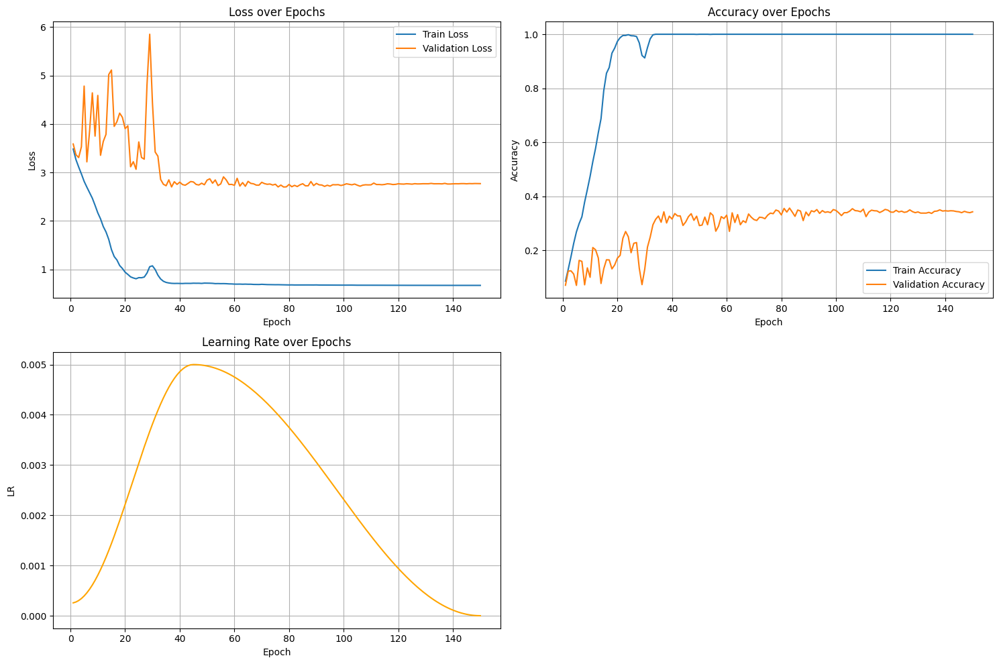

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=False)

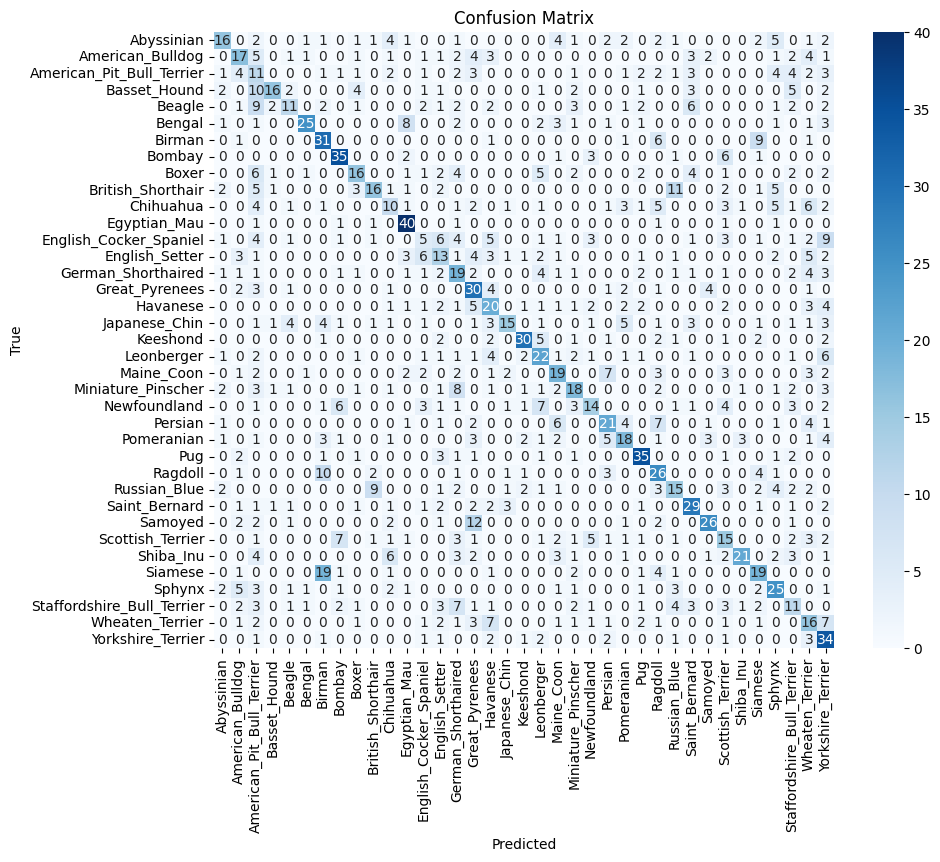

***************************
* Test Accuracy: 0.4117 *
***************************


In [ ]:
best_model_ablation_6 = PetNet(num_classes=test_dataset.get_num_classes()).to(device)
best_model_ablation_6.load_state_dict(torch.load("model_ablation_6.pth"))

test_acc = test_epoch(best_model_ablation_6, test_loader, class_names)

#Add info to Comparison
ablation_6_stat['test_accuracy'] = test_acc
stats.append(ablation_6_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Learning Rate Scheduler

As part of the ablation study, the **learning rate scheduler (OneCycleLR)** was removed, and the model was trained using a **constant learning rate** instead.  
This modification allows us to isolate and evaluate the specific contribution of the scheduler to the model’s convergence speed, stability, and overall performance.

In [ ]:
model_ablation_7 = PetNet(num_classes=train_dataset.get_num_classes()).to(device)

print(model_ablation_7)
print("\nParameters and FLOPs:\n")
ablation_7_stat = model_stats(model_ablation_7, (1, 3, 128, 128))

PetNet(
  (initial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

In [ ]:
#Restore original Data Augmentation
train_dataset = OxfordPetDataset(split="train", transform=train_transform)
val_dataset = OxfordPetDataset(split="val", transform=val_transform)
test_dataset = OxfordPetDataset(split="test", transform=val_transform)

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=hyperparameters['batch_size'], shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=hyperparameters['batch_size'], shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=hyperparameters['batch_size'], shuffle=False, num_workers=4)

#Define the Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing=hyperparameters['label_smoothing'])

#Define the Optimizer
optimizer = optim.AdamW(model_ablation_7.parameters(), lr=hyperparameters['lr'], weight_decay=hyperparameters['weight_decay'])

#Define the Learning Rate Scheduler
#None in this ablation

train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model=model_ablation_7,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None, #<-- Here the Ablation
    num_epochs=hyperparameters['num_epochs'],
    mix_up=hyperparameters['mix_up'],
    mixup_start_epoch=hyperparameters['mixup_start_epoch'],
    device=device,
    save_path="model_ablation_7.pth",
    history_prefix="model_ablation_7"
)

100%|██████████| 58/58 [00:24<00:00,  2.39it/s]


Epoch 1/150
  Train loss: 3.6013, accuracy: 0.0436
  Val   loss: 3.6702, accuracy: 0.0540
  Learning rate: 0.001000


100%|██████████| 58/58 [00:23<00:00,  2.50it/s]


Epoch 2/150
  Train loss: 3.5212, accuracy: 0.0594
  Val   loss: 3.7011, accuracy: 0.0507
  Learning rate: 0.001000


100%|██████████| 58/58 [00:22<00:00,  2.53it/s]


...

Epoch 148/150
  Train loss: 1.5057, accuracy: 0.8232
  Val   loss: 2.0445, accuracy: 0.5654
  Learning rate: 0.001000


100%|██████████| 58/58 [00:22<00:00,  2.53it/s]


Epoch 149/150
  Train loss: 1.5397, accuracy: 0.8038
  Val   loss: 2.1515, accuracy: 0.5333
  Learning rate: 0.001000


100%|██████████| 58/58 [00:23<00:00,  2.48it/s]


Epoch 150/150
  Train loss: 1.5954, accuracy: 0.7901
  Val   loss: 2.0616, accuracy: 0.5529
  Learning rate: 0.001000
Training complete. History saved.


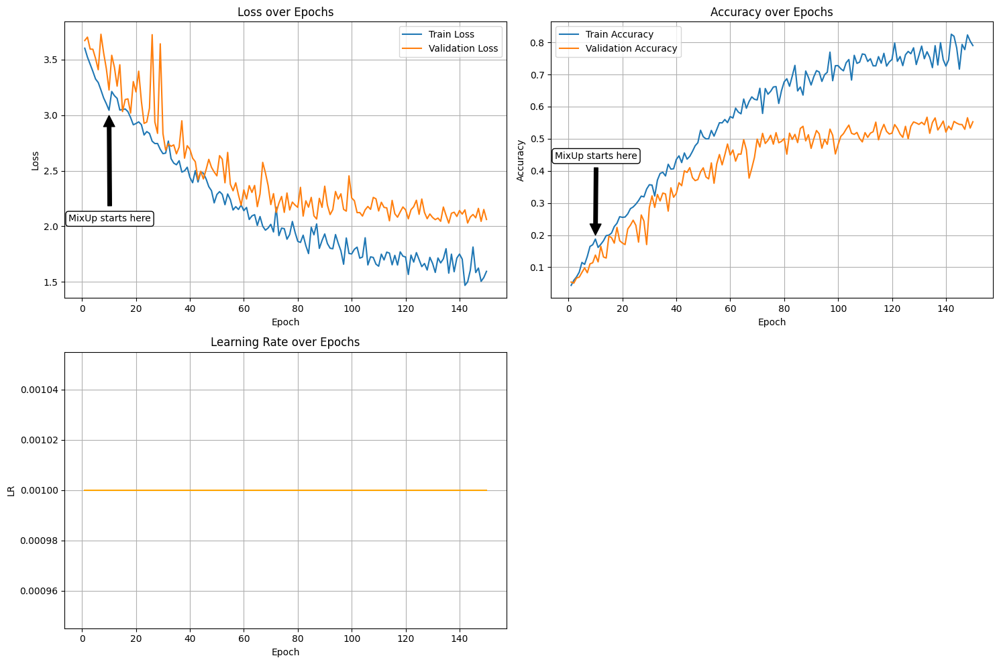

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=True, mixup_start_epoch=10)

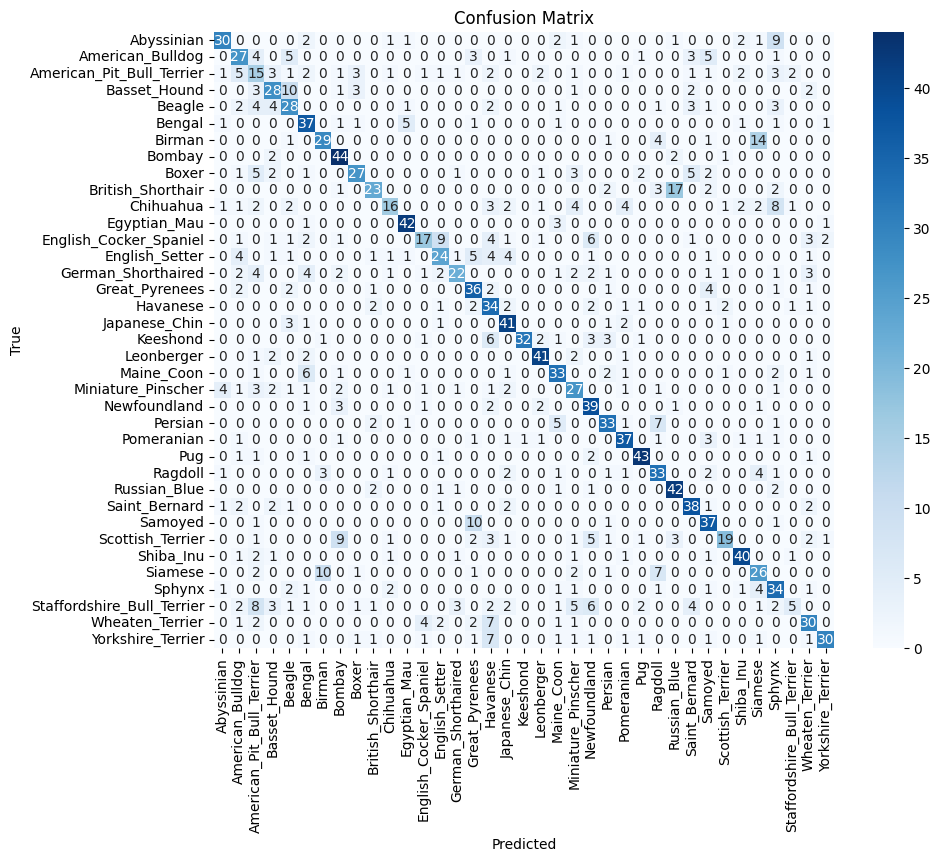

***************************
* Test Accuracy: 0.6170 *
***************************


In [ ]:
best_model_ablation_7 = PetNet(num_classes=test_dataset.get_num_classes()).to(device)
best_model_ablation_7.load_state_dict(torch.load("model_ablation_7.pth"))

test_acc = test_epoch(best_model_ablation_7, test_loader, class_names)

#Add info to Comparison
ablation_7_stat['test_accuracy'] = test_acc
stats.append(ablation_7_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

## Ablation Study Summary

Here, the summary of the ablation results:

### Performance and Training Dynamics

In [ ]:
labels = ['Baseline', 'Ablation 1', 'Ablation 2', 'Ablation 3', 'Ablation 4', 'Ablation 5', 'Ablation 6', 'Ablation 7']
create_stats_dataframe(stats, labels)


,Name,Test Accuracy,% Change (Accuracy),Parameters,% Change (Parameters),MFLOPs,% Change (FLOPs)
0,Baseline,70.48,+0.00%,"4,723,909",+0.00%,"6,441",+0.00%
1,Ablation 1,64.30,-8.77%,"1,173,445",-75.16%,"4,855",-24.62%
2,Ablation 2,67.12,-4.77%,"4,723,909",+0.00%,"6,441",+0.00%
3,Ablation 3,39.60,-43.81%,"4,720,069",-0.08%,"6,441",+0.00%
4,Ablation 4,67.06,-4.85%,"4,723,909",+0.00%,"6,441",+0.00%
5,Ablation 5,67.98,-3.55%,"4,723,909",+0.00%,"6,441",+0.00%
6,Ablation 6,41.17,-41.59%,"4,723,909",+0.00%,"6,441",+0.00%
7,Ablation 7,61.70,-12.46%,"4,723,909",+0.00%,"6,441",+0.00%


The ablation study reveals several key insights into the contributions of various components of the model architecture and training pipeline to the overall performance.

From the results, it is clear that **data augmentation** plays a pivotal role. The baseline model, which includes full data augmentation and MixUp, achieves the highest accuracy of **70.48%**. When MixUp is removed (ablation_5), there is a moderate drop to **67.98%** (-3.55%), and when all data augmentation is removed (ablation_6), the model fails to generalize well, confirming the crucial role of data diversity for small datasets.

This is especially relevant because our dataset is **relatively small** and split in a **50/25/25 ratio** (train/val/test). With such limited training data, the model has fewer examples to learn from, which increases the risk of overfitting. Data augmentation mitigates this by synthetically expanding the training set, exposing the model to a wider range of inputs and promoting better generalization.

The ablation of **Batch Normalization (ablation_3)** has the most severe negative impact on accuracy, dropping to **39.60%** (-43.81%). This highlights how BatchNorm is essential for stable and efficient training by normalizing activations and enabling deeper networks to converge.

As part of the **ablation study (ablation_1)**, the model’s depth was reduced by removing one convolutional block.  
This modification drastically decreased the total number of parameters by **-75.16%** and reduced computational cost by **-24.62% MFLOPs**.  
However, it also caused a significant **drop in accuracy of -8.77%**, indicating that the removed layers contributed crucially to the model’s ability to learn and represent complex visual features.

Replacing **Global Average Pooling** with **MaxPooling** (ablation_4) resulted in a decrease of **4.85%** in accuracy, suggesting that global spatial information aggregation (as done by GAP) is slightly better suited for the task than local maximum operations.

Removing **Label Smoothing** (ablation_2) slightly decreases accuracy (-4.77%), suggesting that it provides a mild regularization benefit.

Removing the **OneCycleLR**  scheduler (ablation_7) led to a noticeable **drop in performance of -12.46%**. This result highlights the importance of dynamic learning rate adjustment during training.The **OneCycleLR** policy appears to significantly enhance model convergence and generalization, confirming its crucial role in optimizing the learning dynamics and achieving better overall performance.

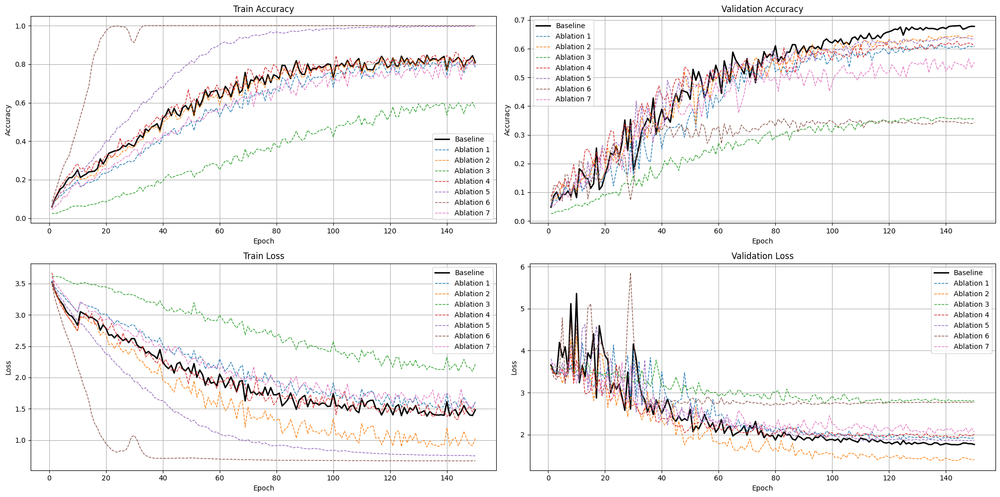

In [ ]:
colors = ['black', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
linestyles = ['-', '--', '--', '--', '--', '--', '--', '--']

plot_training_results(train_accuracies_list, val_accuracies_list, train_losses_list, val_losses_list, labels, colors, linestyles, figsize=(20, 10))

The comparison of training and validation curves across the baseline and the seven ablated models reveals several key insights:

- The **baseline model** achieved the best balance between convergence speed, stability, and generalization, with both train accuracy and train loss curves showing smooth and consistent trends.

- Regarding the **validation accuracy**, the baseline model outperforms all the ablation variants, while in terms of **validation loss**, only **ablation_2** achieves a lower value. This can be explained by the fact that **ablation_2** removes the **label smoothing**. By doing that, the model *attempts to push the correct class score towards infinity*, leading to overconfident predictions. Although **this may reduce the loss numerically**, it often harms generalization, as the model becomes less calibrated and more prone to overfitting.

- In contrast, most **ablated variants** exhibited a noticeable decline in validation accuracy and higher validation loss, highlighting the contribution of the removed components to model performance.

- Interestingly, **ablation_5** and **ablation_6** achieved **higher training accuracy** and **lower training loss** than the baseline, yet their **validation accuracy** was **lower**.  
This divergence between training and validation performance indicates **overfitting**, meaning that these models learned the training data too well but failed to generalize effectively to unseen samples.

- It can also be observed in the training curves that, when **mixup** starts (its application being delayed by 10 epochs to allow the network to stabilize), there is a drop in accuracy and an increase in loss. This happens because mixup generates interpolated samples and blended labels, making the classification task **temporarily more ambiguous**. As a result, the network needs to adapt to these mixed representations, which initially reduces accuracy and increases loss, but ultimately improves generalization and robustness.

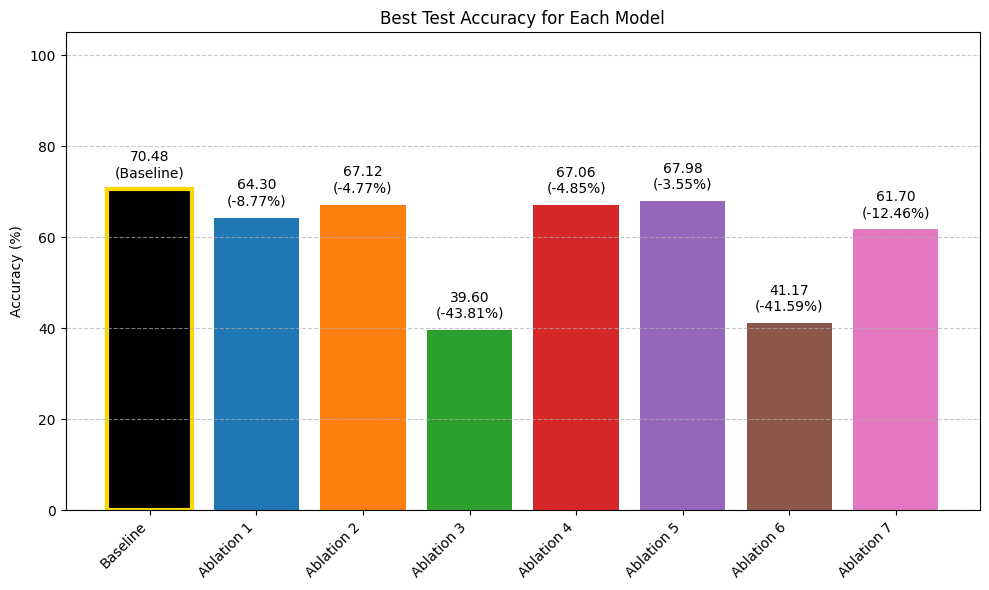

In [ ]:
test_accuracies = [d["test_accuracy"] for d in stats]

plot_test_accuracies(test_accuracies, labels, colors)

### Overall Conclusions

In summary, the results demonstrate that:
- **Data augmentation** (especially with MixUp) is essential for generalization in small datasets.
- **Batch Normalization** is critical for learning stable and useful representations.
- **Model depth** contributes positively to accuracy, but at a cost in parameter count and FLOPs.
- **Global Average Pooling** is preferable over MaxPooling in the classification head.
- **Label Smoothing** offers moderate regularization benefits.
- A **Learning Rate Scheduler** provide better convergence and more stable learning dynamics.

# **Part 2: fine-tune an existing network**

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

## Model Setup and Layer Freezing

We define a simple utility function `get_model` that returns a ResNet-18 model adapted to a custom classification task. The number of output classes is specified through the `num_classes` argument, and optionally, pretrained weights can be loaded by passing them to the `weights` argument. The final fully connected layer is replaced to match the target number of classes

To support transfer learning and fine-tuning strategies, we also define a helper function `set_requires_grad` to control whether a given layer should be trainable by modifying the `requires_grad` attribute of its parameters. Setting this to `False` effectively freezes the layer, preventing it from updating during backpropagation

In [ ]:
def get_model(num_classes, weights = None ):
    model = resnet18(weights= weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

def set_requires_grad(layer, train):
    for p in layer.parameters():
        p.requires_grad = train

## 2A. Fine Tuning with Original Hyperparameters

In this experiment, we fine-tune a ResNet-18 model for image classification using hyperparameters originally optimized for the previous architecture. The goal is to evaluate how well ResNet-18 performs when only its classifier layer is trained, while all other layers remain frozen. This is a common transfer learning strategy that leverages pretrained features without updating the convolutional backbone.

Under these conditions, the model achieved a test accuracy of approximately **62.57%**. This outcome highlights the limitations of directly transferring hyperparameters across architectures without adaptation, particularly when the majority of the network remains frozen.

In [ ]:
#Some Variables for final Comparison

stats = []

train_accuracies_list = []
val_accuracies_list = []
train_losses_list = []
val_losses_list = []

In [ ]:
original_cfg = {
    #Resizing
    "resize_size": 128,
    "crop_size": 128,

    #Training
    "batch_size": 64,
    "num_epochs": 150,

    #Initial lr
    "lr": 1e-3,

    #Regularization
    "wd": 1e-4,
    "label_smoothing": 0.1,

    #Data Augmentation
    "mix_up": 0.4,
    "mixup_start_epoch": 10
}

In [ ]:
mean_image_net = [0.485, 0.456, 0.406]
std_image_net = [0.229, 0.224, 0.225]

original_train_transform = transforms.Compose([ transforms.RandomResizedCrop(original_cfg["crop_size"], scale=(0.8, 1.2)),
                                                transforms.Resize((original_cfg["crop_size"], original_cfg["crop_size"])),
                                                transforms.RandomHorizontalFlip(),
                                                transforms.RandomRotation(30),
                                                transforms.ColorJitter(brightness= 0.2, contrast= 0.2, saturation= 0.2, hue= 0.1),
                                                transforms.RandomAffine(0, translate=(0.1, 0.1)),
                                                transforms.ToTensor(),
                                                transforms.Normalize(mean_image_net, std_image_net),
                                                transforms.RandomErasing(p= 0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random')])

original_val_transform = transforms.Compose([ transforms.Resize((original_cfg["resize_size"], original_cfg["resize_size"])),
                                              transforms.ToTensor(),
                                              transforms.Normalize(mean_image_net, std_image_net)])


# Dataset
train_dataset = OxfordPetDataset(split= "train", transform= original_train_transform)
val_dataset = OxfordPetDataset(split= "val", transform= original_val_transform)
test_dataset = OxfordPetDataset(split= "test", transform= original_val_transform)

# DataLoader
original_train_loader = DataLoader( train_dataset, batch_size= original_cfg["batch_size"], shuffle= True, num_workers= 4)
original_val_loader = DataLoader( val_dataset, batch_size= original_cfg["batch_size"], shuffle= False, num_workers= 4)
original_test_loader = DataLoader( test_dataset, batch_size= original_cfg["batch_size"], shuffle= False, num_workers= 4)

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_original_hyperparams = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_original_hyperparams.conv1, False)
set_requires_grad(resnet_original_hyperparams.bn1, False)
set_requires_grad(resnet_original_hyperparams.layer1, False)
set_requires_grad(resnet_original_hyperparams.layer2, False)
set_requires_grad(resnet_original_hyperparams.layer3, False)
set_requires_grad(resnet_original_hyperparams.layer4, False)

print(resnet_original_hyperparams)
print("\nParameters and FLOPs:\n")
res_net_original_stat = model_stats(resnet_original_hyperparams, (1, 3, original_cfg['crop_size'], original_cfg['crop_size']))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= original_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW(resnet_original_hyperparams.parameters(),
                        lr= original_cfg["lr"],
                        weight_decay= original_cfg["wd"])

#Learning Rate Scheduler
steps_per_epoch = len(original_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= original_cfg["lr"],
                        total_steps= original_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_original_hyperparams,
    train_loader= original_train_loader,
    val_loader= original_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= original_cfg["num_epochs"],

    mix_up= original_cfg["mix_up"],
    mixup_start_epoch= original_cfg["mixup_start_epoch"],

    device= device,
    save_path= "original_hyperparameters.pth",
    history_prefix= "original_hyperparameters")

100%|██████████| 58/58 [00:22<00:00,  2.60it/s]


Epoch 1/150
  Train loss: 3.7609, accuracy: 0.0316
  Val   loss: 3.7101, accuracy: 0.0349
  Learning rate: 0.000051


100%|██████████| 58/58 [00:21<00:00,  2.66it/s]


Epoch 2/150
  Train loss: 3.6341, accuracy: 0.0428
  Val   loss: 3.5754, accuracy: 0.0556
  Learning rate: 0.000055


100%|██████████| 58/58 [00:20<00:00,  2.78it/s]


...

Epoch 148/150
  Train loss: 2.3888, accuracy: 0.4841
  Val   loss: 1.8903, accuracy: 0.6058
  Learning rate: 0.000001


100%|██████████| 58/58 [00:22<00:00,  2.54it/s]


Epoch 149/150
  Train loss: 2.3693, accuracy: 0.4899
  Val   loss: 1.8959, accuracy: 0.5938
  Learning rate: 0.000000


100%|██████████| 58/58 [00:22<00:00,  2.54it/s]


Epoch 150/150
  Train loss: 2.4379, accuracy: 0.4732
  Val   loss: 1.8990, accuracy: 0.5954
  Learning rate: 0.000000
Training complete. History saved.


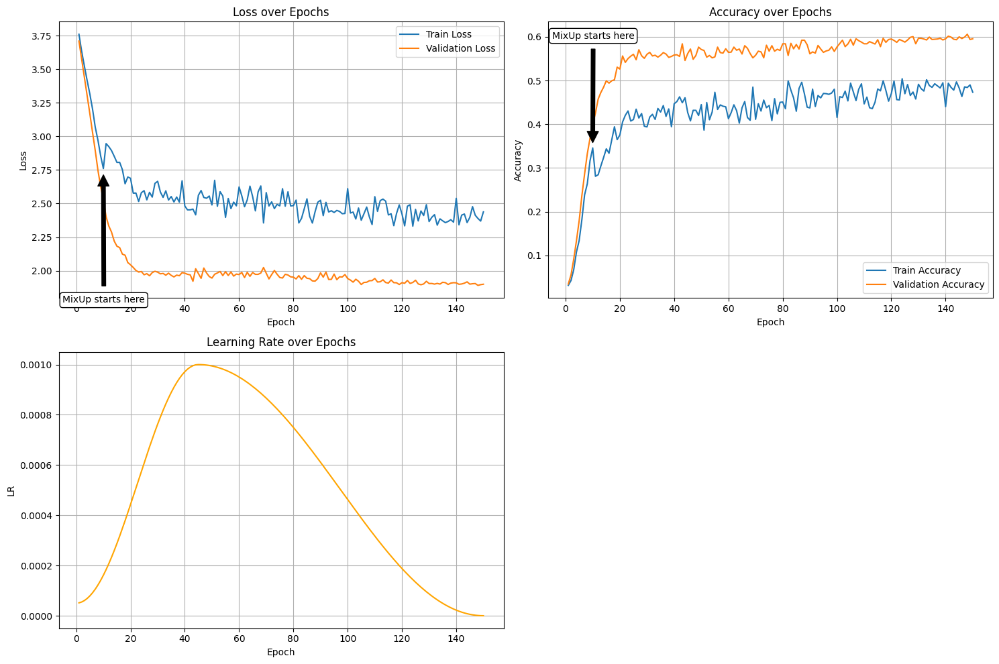

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=True)

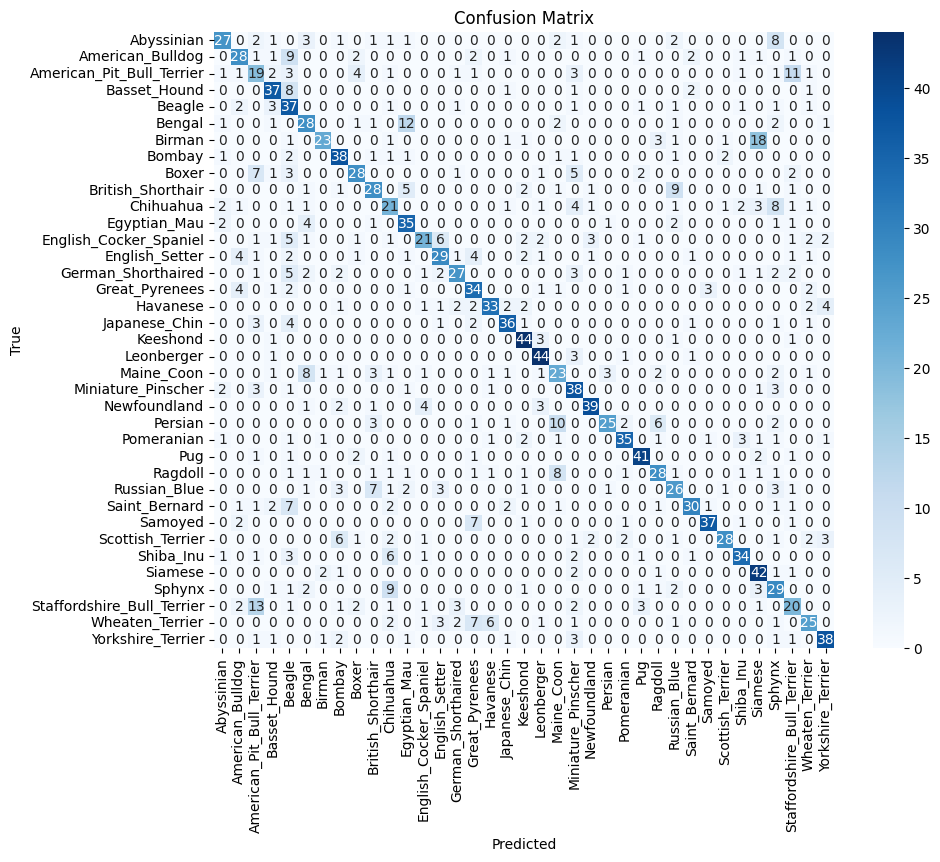

***************************
* Test Accuracy: 0.6257 *
***************************


In [ ]:
resnet_original_hyperparams.load_state_dict(torch.load("original_hyperparameters.pth"))
test_acc = test_epoch(resnet_original_hyperparams, original_test_loader, class_names)

#Add info to Comparison
res_net_original_stat['test_accuracy'] = test_acc
stats.append(res_net_original_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

## 2B. Tweaking Hyperparameters

Before reporting the most significant examples, we trained a wide variety of hyperparameter combinations. However, we eventually decided to limit training to 50 epochs, as we observed that accuracy improvements plateaued beyond that point. This decision considerably reduced the overall training time without sacrificing model performance.

In the initial experiments, we only unfroze the classifier layer of the pretrained ResNet-18. This allowed for faster training while fine-tuning the model to our specific task. Later on, we provide evidence on the behavior of unfreezing layers at different depths, using the most promising hyperparameter settings identified during earlier trials.

Regarding the mini-batch size, we experimented with multiple settings. However, the observed performance trends were similar to those seen with longer training durations: improvements beyond a certain point were marginal. To streamline the training process, we ultimately fixed the batch size at **32** across all configurations.


### Different Sizes in Resizing and Cropping

The first adaptation implemented was adjusting the image preprocessing pipeline to fit the typical input dimensions expected by ResNet models. This involved resizing and cropping the images to match the standard shape (e.g., 224×224 pixels), ensuring compatibility with the ResNet architecture and maintaining consistency with common training practices.

As we can see from the results below, this gave a major boost to the model’s performance. The original image sizes tended to extract only a small portion of the content, limiting the amount of useful information available to the network. After this adjustment, the model achieved a test accuracy of **85.32%**.

In [ ]:
resized_cfg = {

    #Resizing
    "resize_size": 256, # <-- Here the change(s)
    "crop_size": 224, # <-- Here the change(s)

    #Training
    "batch_size": 32, # <-- Here the change(s)
    "num_epochs": 50, # <-- Here the change(s)

    #Initial lr
    "lr": 1e-3,

    #Regularization
    "wd": 1e-4,
    "label_smoothing": 0.1,

    #Data Augmentation
    "mix_up": 0.4,
    "mixup_start_epoch": 10
}

In [ ]:
resized_train_transform = transforms.Compose([ transforms.RandomResizedCrop(resized_cfg["crop_size"], scale=(0.8, 1.2)),
                                               transforms.RandomHorizontalFlip(),
                                               transforms.RandomRotation(30),
                                               transforms.ColorJitter(brightness= 0.2, contrast= 0.2, saturation= 0.2, hue= 0.1),
                                               transforms.RandomAffine(0, translate=(0.1, 0.1)),
                                               transforms.ToTensor(),
                                               transforms.Normalize(mean_image_net, std_image_net),
                                               transforms.RandomErasing(p= 0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random')])

resized_val_transform = transforms.Compose([ transforms.Resize(resized_cfg["resize_size"]),
                                                 transforms.CenterCrop(resized_cfg["crop_size"]),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean_image_net, std_image_net)])

# Dataset
train_dataset = OxfordPetDataset(split= "train", transform= resized_train_transform)
val_dataset = OxfordPetDataset(split= "val", transform= resized_val_transform)
test_dataset = OxfordPetDataset(split= "test", transform= resized_val_transform)

# DataLoader
resized_train_loader = DataLoader( train_dataset, batch_size= resized_cfg["batch_size"], shuffle= True, num_workers= 4)
resized_val_loader = DataLoader( val_dataset, batch_size= resized_cfg["batch_size"], shuffle= False, num_workers= 4)
resized_test_loader = DataLoader( test_dataset, batch_size= resized_cfg["batch_size"], shuffle= False, num_workers= 4)

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_resized = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_resized.conv1, False)
set_requires_grad(resnet_resized.bn1, False)
set_requires_grad(resnet_resized.layer1, False)
set_requires_grad(resnet_resized.layer2, False)
set_requires_grad(resnet_resized.layer3, False)
set_requires_grad(resnet_resized.layer4, False)

print(resnet_resized)
print("\nParameters and FLOPs:\n")
resnet_resized_stat = model_stats(resnet_resized, (1, 3, resized_cfg['crop_size'], resized_cfg['crop_size']))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= resized_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW(resnet_resized.parameters(),
                        lr= resized_cfg["lr"],
                        weight_decay= resized_cfg["wd"])

#Learning Rate Scheduler
steps_per_epoch = len(resized_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= resized_cfg["lr"],
                        total_steps= resized_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_resized,
    train_loader= resized_train_loader,
    val_loader= resized_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= resized_cfg["num_epochs"],

    mix_up= resized_cfg["mix_up"],
    mixup_start_epoch= resized_cfg["mixup_start_epoch"],

    device= device,
    save_path= "resized.pth",
    history_prefix= "resized")

100%|██████████| 115/115 [00:38<00:00,  3.02it/s]


Epoch 1/50
  Train loss: 3.6336, accuracy: 0.0417
  Val   loss: 3.4386, accuracy: 0.0998
  Learning rate: 0.000060


100%|██████████| 115/115 [00:36<00:00,  3.15it/s]


Epoch 2/50
  Train loss: 3.3736, accuracy: 0.1360
  Val   loss: 3.1314, accuracy: 0.2519
  Learning rate: 0.000091


100%|██████████| 115/115 [00:37<00:00,  3.09it/s]


...

Epoch 48/50
  Train loss: 1.9911, accuracy: 0.6461
  Val   loss: 1.2350, accuracy: 0.8304
  Learning rate: 0.000008


100%|██████████| 115/115 [00:35<00:00,  3.22it/s]


Epoch 49/50
  Train loss: 1.8442, accuracy: 0.6968
  Val   loss: 1.2335, accuracy: 0.8337
  Learning rate: 0.000002


100%|██████████| 115/115 [00:35<00:00,  3.25it/s]


Epoch 50/50
  Train loss: 1.9209, accuracy: 0.6612
  Val   loss: 1.2373, accuracy: 0.8282
  Learning rate: 0.000000
Training complete. History saved.


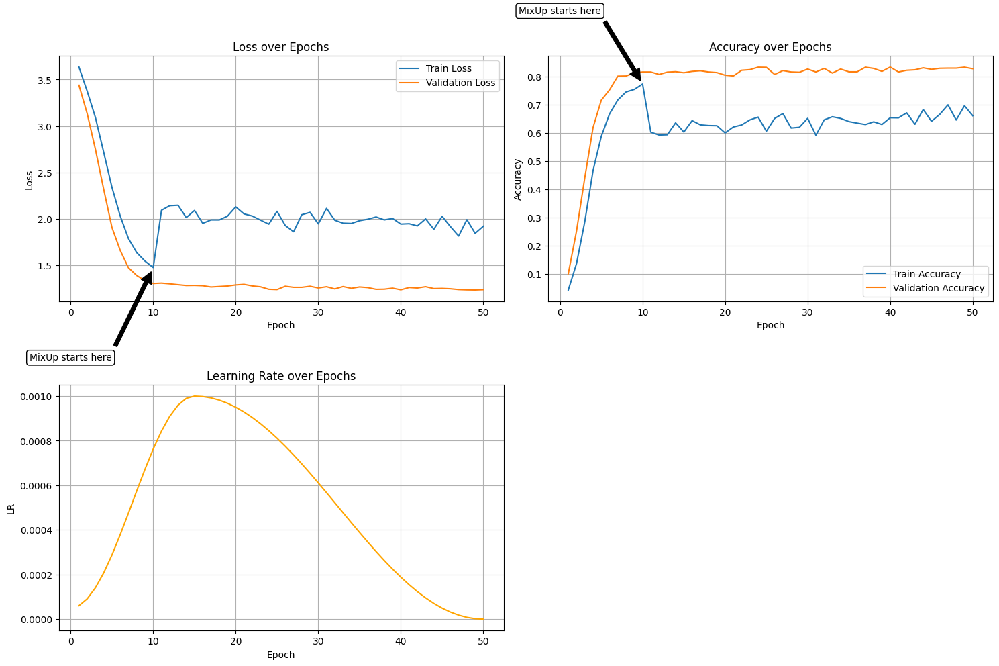

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=True)

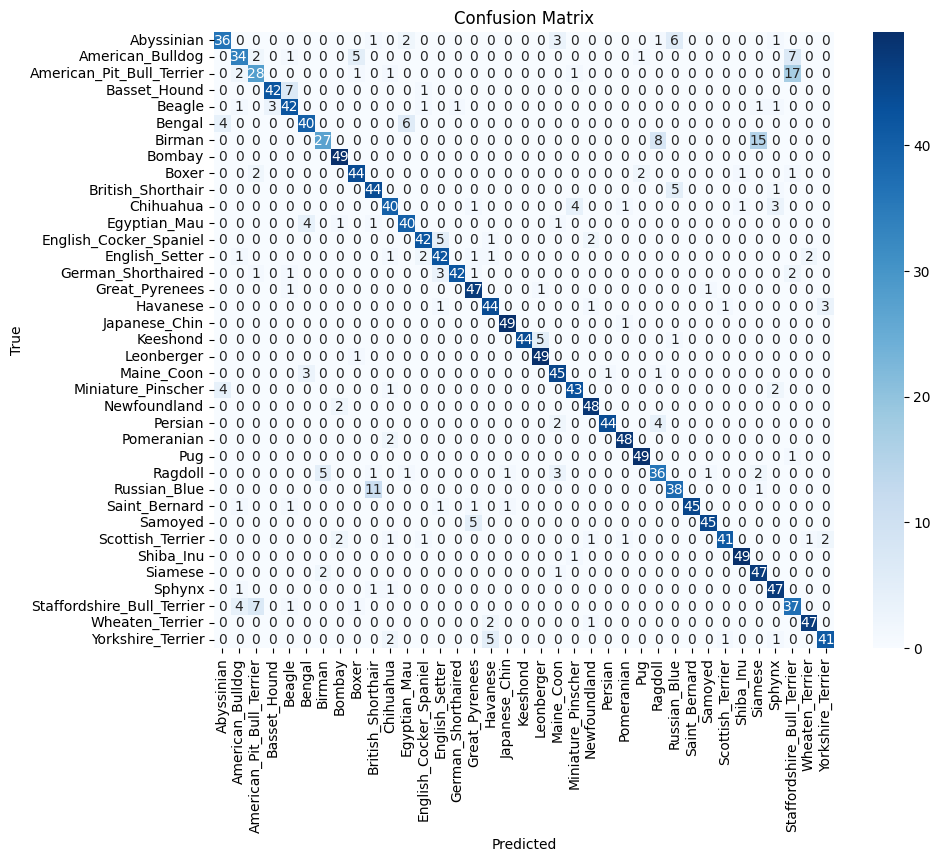

***************************
* Test Accuracy: 0.8532 *
***************************


In [ ]:
resnet_resized.load_state_dict(torch.load("resized.pth"))
test_acc = test_epoch(resnet_resized, resized_test_loader, class_names)

#Add info to Comparison
resnet_resized_stat['test_accuracy'] = test_acc
stats.append(resnet_resized_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Reducing Aggressive Augmentations

The second adaptation involved reducing the use of aggressive data augmentations. Since ResNet-18 has already been pretrained on a large and diverse dataset, it has a strong ability to generalize, especially when only the classifier is unfrozen, as in our initial experiments.

After inspecting our dataset, we decided to keep only a mild color jitter. This decision was based on the observation that most of the variations in our data seemed to come from changes in lighting and other subtle visual differences. Stronger augmentations didn’t appear necessary and could even distract the model from learning relevant features.

As we can see from the results, this relaxation provided an increase in performance of around **3%**, reaching an accuracy of **88.03%**, confirming that simpler augmentations were better suited to our specific task and model setup.

In [ ]:
lowered_augmentations_cfg = {
    #Resizing
    "resize_size": 256,
    "crop_size": 224,

    #Training
    "batch_size": 32,
    "num_epochs": 50,

    #Initial lr
    "lr": 1e-3,

    #Regularization
    "wd": 1e-4,
    "label_smoothing": 0.1,

    #Data Augmentation
    "mix_up": 0.4,
    "mixup_start_epoch": 10
}

In [ ]:
lowered_augmentations_train_transform = transforms.Compose([ transforms.RandomResizedCrop(lowered_augmentations_cfg["crop_size"]),#, scale=(0.8, 1.2)), # <-- Here the change(s)
                                                             transforms.RandomHorizontalFlip(),
                                                             #transforms.RandomRotation(30), # <-- Here the change(s)
                                                             transforms.ColorJitter(brightness= 0.1, contrast= 0.1, saturation= 0.1, hue= 0.1),
                                                             #transforms.RandomAffine(0, translate=(0.1, 0.1)), # <-- Here the change(s)
                                                             transforms.ToTensor(),
                                                             transforms.Normalize(mean_image_net, std_image_net)])
                                                             #transforms.RandomErasing(p= 0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random')]) # <-- Here the change(s)

lowered_augmentations_val_transform = transforms.Compose([ transforms.Resize(lowered_augmentations_cfg["resize_size"]),
                                                           transforms.CenterCrop(lowered_augmentations_cfg["crop_size"]),
                                                           transforms.ToTensor(),
                                                           transforms.Normalize(mean_image_net, std_image_net)])

# Dataset
train_dataset = OxfordPetDataset(split= "train", transform= lowered_augmentations_train_transform)
val_dataset = OxfordPetDataset(split= "val", transform= lowered_augmentations_val_transform)
test_dataset = OxfordPetDataset(split= "test", transform= lowered_augmentations_val_transform)

# DataLoader
lowered_augmentations_train_loader = DataLoader( train_dataset, batch_size= lowered_augmentations_cfg["batch_size"], shuffle= True, num_workers= 4)
lowered_augmentations_val_loader = DataLoader( val_dataset, batch_size= lowered_augmentations_cfg["batch_size"], shuffle= False, num_workers= 4)

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_lowered_augmentations = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_lowered_augmentations.conv1, False)
set_requires_grad(resnet_lowered_augmentations.bn1, False)
set_requires_grad(resnet_lowered_augmentations.layer1, False)
set_requires_grad(resnet_lowered_augmentations.layer2, False)
set_requires_grad(resnet_lowered_augmentations.layer3, False)
set_requires_grad(resnet_lowered_augmentations.layer4, False)

print(resnet_lowered_augmentations)
print("\nParameters and FLOPs:\n")
resnet_lowered_augmentations_stat = model_stats(resnet_lowered_augmentations, (1, 3, lowered_augmentations_cfg['crop_size'], lowered_augmentations_cfg['crop_size']))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= lowered_augmentations_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW(resnet_lowered_augmentations.parameters(),
                        lr= lowered_augmentations_cfg["lr"],
                        weight_decay= lowered_augmentations_cfg["wd"])

#Learning Rate Scheduler
steps_per_epoch = len(lowered_augmentations_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= lowered_augmentations_cfg["lr"],
                        total_steps= lowered_augmentations_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_lowered_augmentations,
    train_loader= lowered_augmentations_train_loader,
    val_loader= lowered_augmentations_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= lowered_augmentations_cfg["num_epochs"],

    mix_up= lowered_augmentations_cfg["mix_up"],
    mixup_start_epoch= lowered_augmentations_cfg["mixup_start_epoch"],

    device= device,
    save_path= "lowered_augmentations.pth",
    history_prefix= "lowered_augmentations")

100%|██████████| 115/115 [00:33<00:00,  3.42it/s]


Epoch 1/50
  Train loss: 3.5432, accuracy: 0.0714
  Val   loss: 3.3412, accuracy: 0.1363
  Learning rate: 0.000060


100%|██████████| 115/115 [00:32<00:00,  3.55it/s]


Epoch 2/50
  Train loss: 3.2619, accuracy: 0.1894
  Val   loss: 2.9705, accuracy: 0.3195
  Learning rate: 0.000091


100%|██████████| 115/115 [00:32<00:00,  3.55it/s]


...

Epoch 48/50
  Train loss: 1.8166, accuracy: 0.7106
  Val   loss: 1.1442, accuracy: 0.8784
  Learning rate: 0.000008


100%|██████████| 115/115 [00:34<00:00,  3.33it/s]


Epoch 49/50
  Train loss: 1.9115, accuracy: 0.6675
  Val   loss: 1.1526, accuracy: 0.8735
  Learning rate: 0.000002


100%|██████████| 115/115 [00:34<00:00,  3.32it/s]


Epoch 50/50
  Train loss: 1.9113, accuracy: 0.6765
  Val   loss: 1.1533, accuracy: 0.8762
  Learning rate: 0.000000
Training complete. History saved.


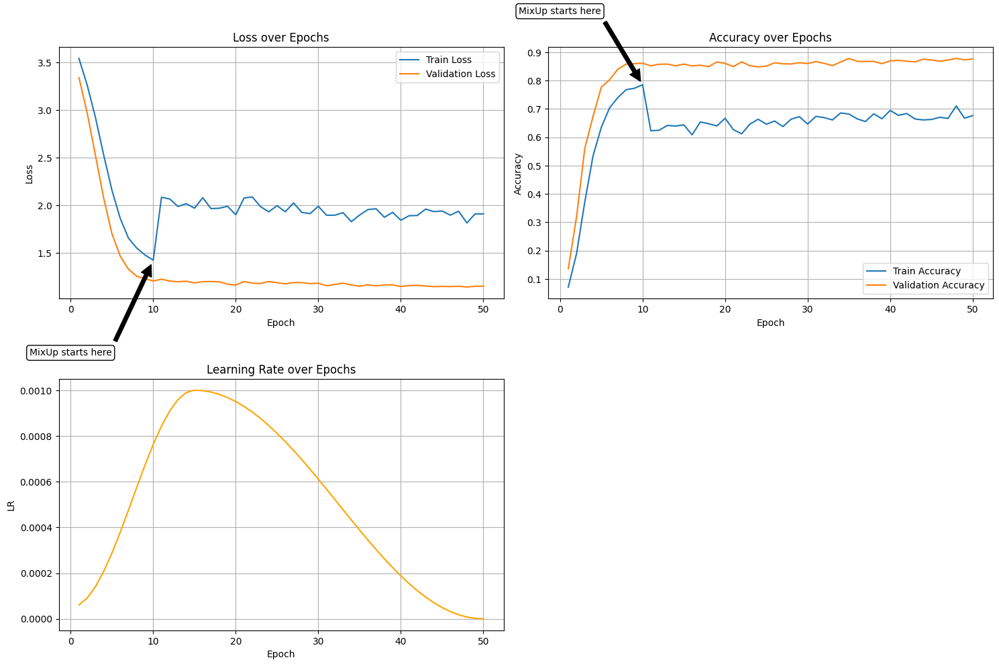

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup=True)

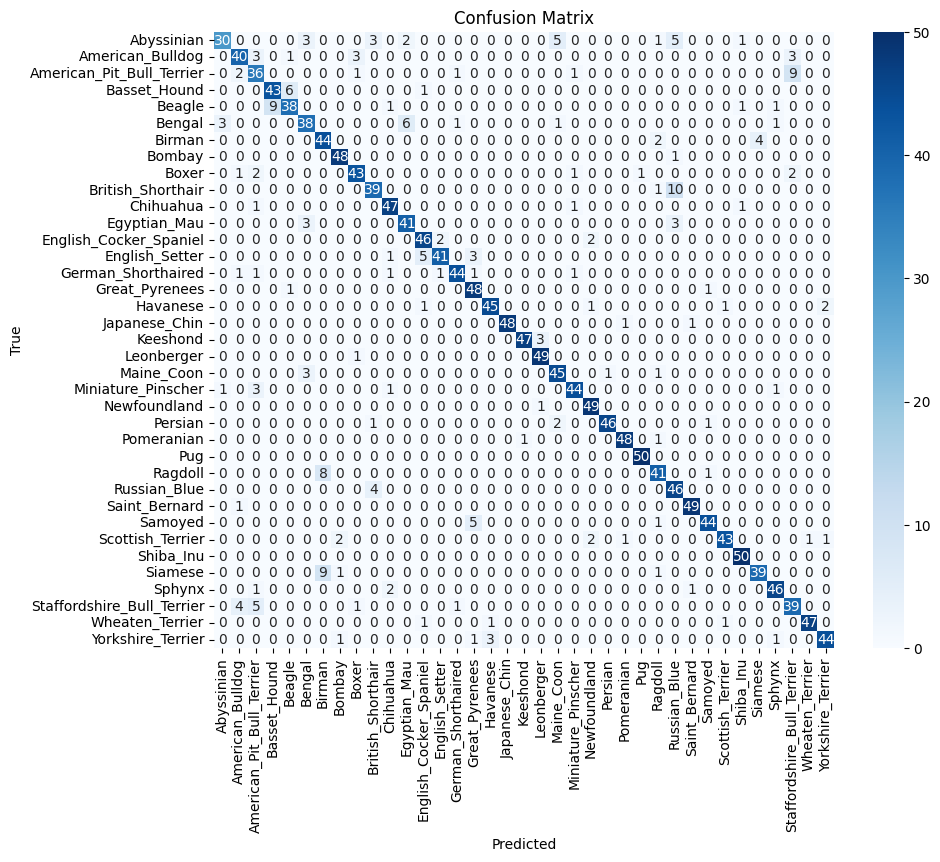

***************************
* Test Accuracy: 0.8803 *
***************************


In [ ]:
resnet_lowered_augmentations.load_state_dict(torch.load("lowered_augmentations.pth"))
test_acc = test_epoch(resnet_lowered_augmentations, resized_test_loader, class_names)

#Add info to Comparison
resnet_lowered_augmentations_stat['test_accuracy'] = test_acc
stats.append(resnet_lowered_augmentations_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Dropping Label Smoothing and Mixup

Another important decision during model optimization was to drop regularization techniques like label smoothing and MixUp. While both are widely used to improve generalization (especially in large-scale classification tasks), they didn’t prove very beneficial in our setting.

Label smoothing slightly distorts the target distribution, which can help prevent overconfidence in predictions. However, in our case, it seemed to hinder learning, likely due to the relatively small size of our dataset and the fact that we were only fine-tuning the classifier.

Similarly, MixUp (which generates new training samples by combining pairs of images and their labels) introduces a level of abstraction that may not align well with fine-tuning only the last layer of a pretrained network. Our preliminary experiments showed a minor drop in performance when using these techniques.

Based on these observations, we opted to remove both regularizations from the training pipeline. This simplification led to more stable training, and an improved test accuracy of **89.17%**, marking our best result up to that point.

In [ ]:
no_smoothing_mixup_cfg = {
    #Resizing
    "resize_size": 256,
    "crop_size": 224,

    #Training
    "batch_size": 32,
    "num_epochs": 50,

    #Initial lr
    "lr": 1e-3,

    #Regularization
    "wd": 1e-4,
    "label_smoothing": 0, # <-- Here the change(s)

    #Data Augmentation
    "mix_up": 0, # <-- Here the change(s)
    "mixup_start_epoch": 0 # <-- Here the change(s)
}

#As Dataloader we can use the ones of previus section since they do not change.

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_no_smoothing_mixup = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_no_smoothing_mixup.conv1, False)
set_requires_grad(resnet_no_smoothing_mixup.bn1, False)
set_requires_grad(resnet_no_smoothing_mixup.layer1, False)
set_requires_grad(resnet_no_smoothing_mixup.layer2, False)
set_requires_grad(resnet_no_smoothing_mixup.layer3, False)
set_requires_grad(resnet_no_smoothing_mixup.layer4, False)

print(resnet_no_smoothing_mixup)
print("\nParameters and FLOPs:\n")
resnet_no_smoothing_mixup_stat = model_stats(resnet_no_smoothing_mixup, (1, 3,no_smoothing_mixup_cfg['crop_size'], no_smoothing_mixup_cfg['crop_size']))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= no_smoothing_mixup_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW(resnet_no_smoothing_mixup.parameters(),
                        lr= no_smoothing_mixup_cfg["lr"],
                        weight_decay= no_smoothing_mixup_cfg["wd"])

#Learning Rate Scheduler
steps_per_epoch = len(lowered_augmentations_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= no_smoothing_mixup_cfg["lr"],
                        total_steps= no_smoothing_mixup_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_no_smoothing_mixup,
    train_loader= lowered_augmentations_train_loader,
    val_loader= lowered_augmentations_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= no_smoothing_mixup_cfg["num_epochs"],

    mix_up= no_smoothing_mixup_cfg["mix_up"],
    mixup_start_epoch= no_smoothing_mixup_cfg["mixup_start_epoch"],

    device= device,
    save_path= "no_smoothing_mixup.pth",
    history_prefix= "no_smoothing_mixup")

100%|██████████| 115/115 [00:34<00:00,  3.35it/s]


Epoch 1/50
  Train loss: 3.6297, accuracy: 0.0384
  Val   loss: 3.4318, accuracy: 0.0638
  Learning rate: 0.000060


100%|██████████| 115/115 [00:32<00:00,  3.55it/s]


Epoch 2/50
  Train loss: 3.3039, accuracy: 0.1284
  Val   loss: 2.9997, accuracy: 0.2454
  Learning rate: 0.000091


100%|██████████| 115/115 [00:32<00:00,  3.59it/s]


...

Epoch 48/50
  Train loss: 0.4826, accuracy: 0.8512
  Val   loss: 0.3670, accuracy: 0.8899
  Learning rate: 0.000008


100%|██████████| 115/115 [00:34<00:00,  3.30it/s]


Epoch 49/50
  Train loss: 0.4711, accuracy: 0.8613
  Val   loss: 0.3627, accuracy: 0.8877
  Learning rate: 0.000002


100%|██████████| 115/115 [00:32<00:00,  3.51it/s]


Epoch 50/50
  Train loss: 0.4839, accuracy: 0.8531
  Val   loss: 0.3609, accuracy: 0.8871
  Learning rate: 0.000000
Training complete. History saved.


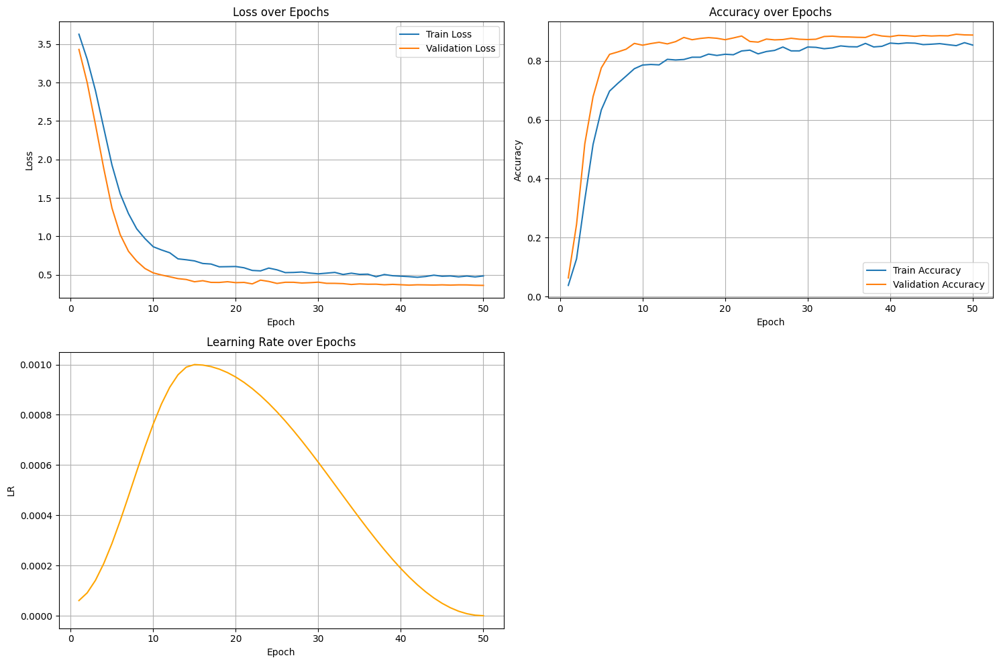

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup= False)

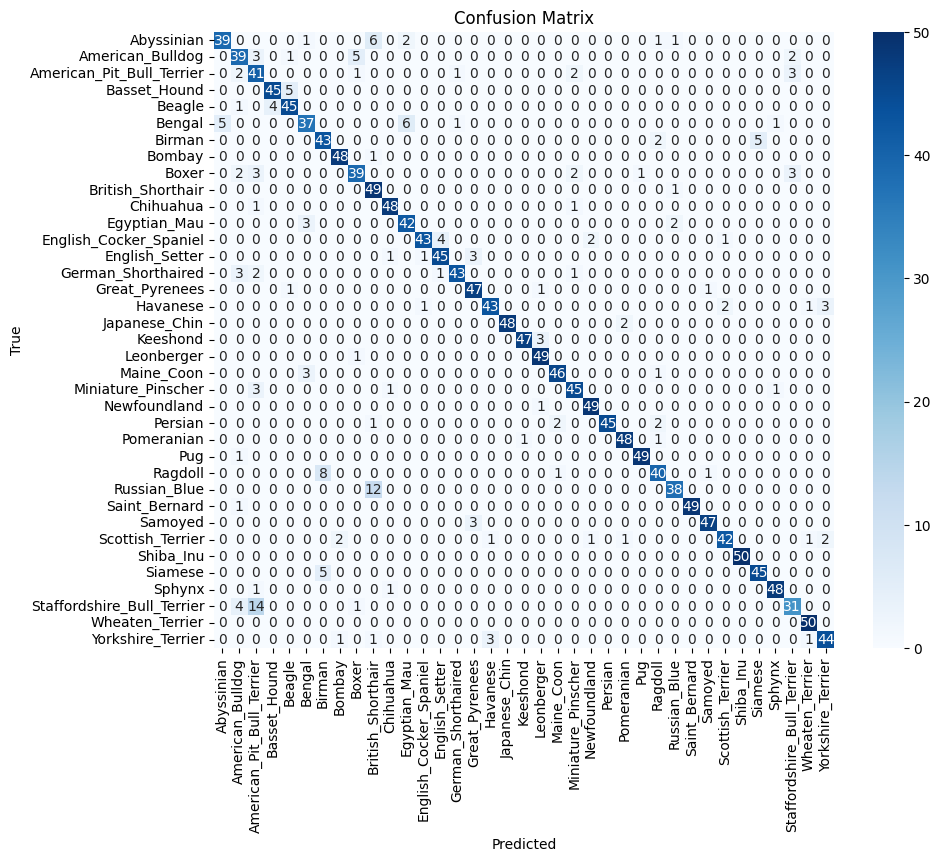

***************************
* Test Accuracy: 0.8917 *
***************************


In [ ]:
resnet_no_smoothing_mixup.load_state_dict(torch.load("no_smoothing_mixup.pth"))
test_acc = test_epoch(resnet_no_smoothing_mixup, resized_test_loader, class_names)

#Add info to Comparison
resnet_no_smoothing_mixup_stat['test_accuracy'] = test_acc
stats.append(resnet_no_smoothing_mixup_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

### Fine-Tuning with Progressive Unfreezing of Residual Layers

In the next phase of our experiments, we explored a more advanced fine-tuning strategy: **progressively unfreezing the residual layers** of the ResNet model. This approach gradually increases model adaptability during training by starting from the final layers—those most specialized for the target task—and then slowly incorporating earlier convolutional blocks originally pretrained on ImageNet.

From preliminary experiments (not reported in this notebook), we identified a key challenge: selecting **appropriate and stable learning rates across different layer groups**. Layers closer to the classifier head benefit from higher learning rates since they must adapt more significantly to the new dataset, whereas early convolutional layers contain general visual representations (e.g., edges, textures) and must be updated cautiously to avoid **catastrophic forgetting**. Without careful learning rate scheduling, training was prone to **loss spikes and convergence instability**, making optimization unreliable.

To address this, we implemented a **layer-wise learning rate strategy** combined with **progressive unfreezing**. However, as more residual layers were unfrozen, generalization performance started to decrease slightly due to the increased model capacity and risk of overfitting. To counteract this effect, we gradually reintroduced regularization methods, including **MixUp augmentation** and **soft label smoothing**, which helped stabilize training while maintaining the model’s ability to adapt.

The evolution of the learning rate during fine-tuning is illustrated in the figures, where the plot shows the learning rate schedule for the last residual block. The learning rate behavior for earlier layers follows the **same exponential decay pattern**, but due to their smaller initial values, their curves are not shown here to avoid compressing the visualization and losing interpretability.

This combined strategy resulted in a **performance improvement of approximately 0.5%**, leading to the best test accuracy of **89.71%** when training the full model with all residual layers unfrozen.

#### Unfreezing layer4

In [ ]:
unfreezing_4_cfg = {
    #Resizing
    "resize_size": 256,
    "crop_size": 224,

    #Training
    "batch_size": 32,
    "num_epochs": 50,

    #Regularization
    "label_smoothing": 0.01,

    #Data Augmentation
    "mix_up": 0.01,
    "mixup_start_epoch": 10
}

#As Dataloader we can use the ones of previus section since they do not change.

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_unfreezing_4 = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_unfreezing_4.conv1, False)
set_requires_grad(resnet_unfreezing_4.bn1, False)
set_requires_grad(resnet_unfreezing_4.layer1, False)
set_requires_grad(resnet_unfreezing_4.layer2, False)
set_requires_grad(resnet_unfreezing_4.layer3, False)
#layer4 requires gradient (as default) <-- Here the change(s)

print(resnet_unfreezing_4)
print("\nParameters and FLOPs:\n")
resnet_unfreezing_4_stat = model_stats(resnet_unfreezing_4, (1, 3, unfreezing_4_cfg['crop_size'], unfreezing_4_cfg['crop_size']))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= unfreezing_4_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW([{'params': resnet_unfreezing_4.fc.parameters(), 'lr': 1e-3, "weight_decay": 1e-4},
                         {'params': resnet_unfreezing_4.layer4.parameters(), 'lr': 1e-4, "weight_decay": 1e-3}])

#Learning Rate Scheduler
steps_per_epoch = len(lowered_augmentations_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= [1e-3, 1e-4],
                        total_steps= unfreezing_4_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_unfreezing_4,
    train_loader= lowered_augmentations_train_loader,
    val_loader= lowered_augmentations_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= unfreezing_4_cfg["num_epochs"],

    mix_up= unfreezing_4_cfg["mix_up"],
    mixup_start_epoch= unfreezing_4_cfg["mixup_start_epoch"],

    device= device,
    save_path= "unfreezing_4.pth",
    history_prefix= "unfreezing_4")

100%|██████████| 115/115 [00:34<00:00,  3.38it/s]


Epoch 1/50
  Train loss: 3.4784, accuracy: 0.0940
  Val   loss: 3.0449, accuracy: 0.2514
  Learning rate: 0.000060


100%|██████████| 115/115 [00:31<00:00,  3.61it/s]


Epoch 2/50
  Train loss: 2.8499, accuracy: 0.3677
  Val   loss: 2.2032, accuracy: 0.6189
  Learning rate: 0.000091


100%|██████████| 115/115 [00:33<00:00,  3.42it/s]


...

Epoch 48/50
  Train loss: 0.3382, accuracy: 0.9522
  Val   loss: 0.5370, accuracy: 0.8806
  Learning rate: 0.000008


100%|██████████| 115/115 [00:31<00:00,  3.61it/s]


Epoch 49/50
  Train loss: 0.3014, accuracy: 0.9544
  Val   loss: 0.5384, accuracy: 0.8811
  Learning rate: 0.000002


100%|██████████| 115/115 [00:33<00:00,  3.48it/s]


Epoch 50/50
  Train loss: 0.3587, accuracy: 0.9386
  Val   loss: 0.5391, accuracy: 0.8828
  Learning rate: 0.000000
Training complete. History saved.


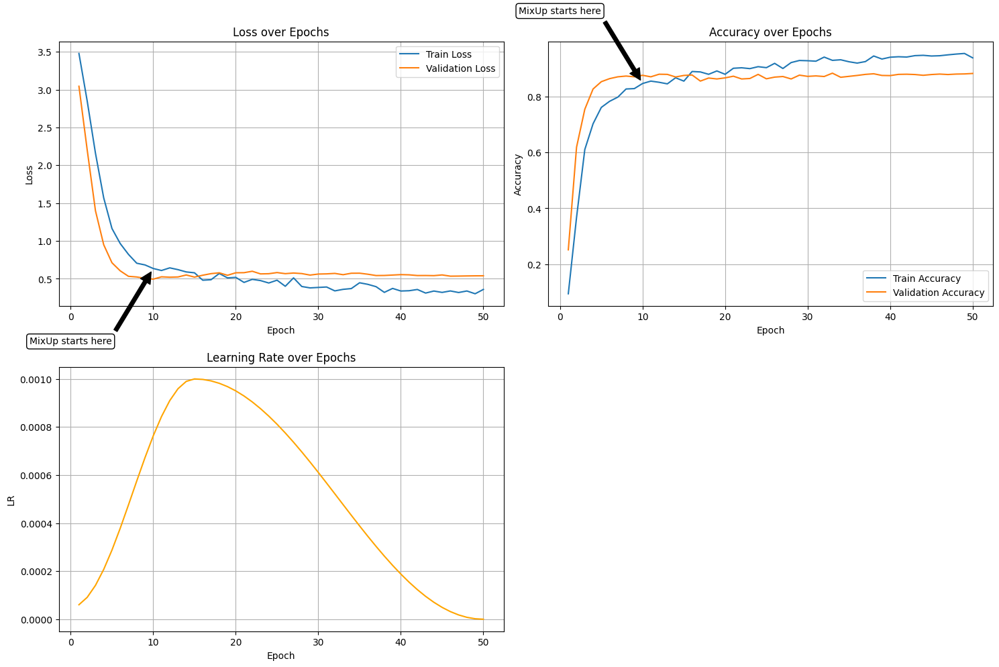

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup= True)

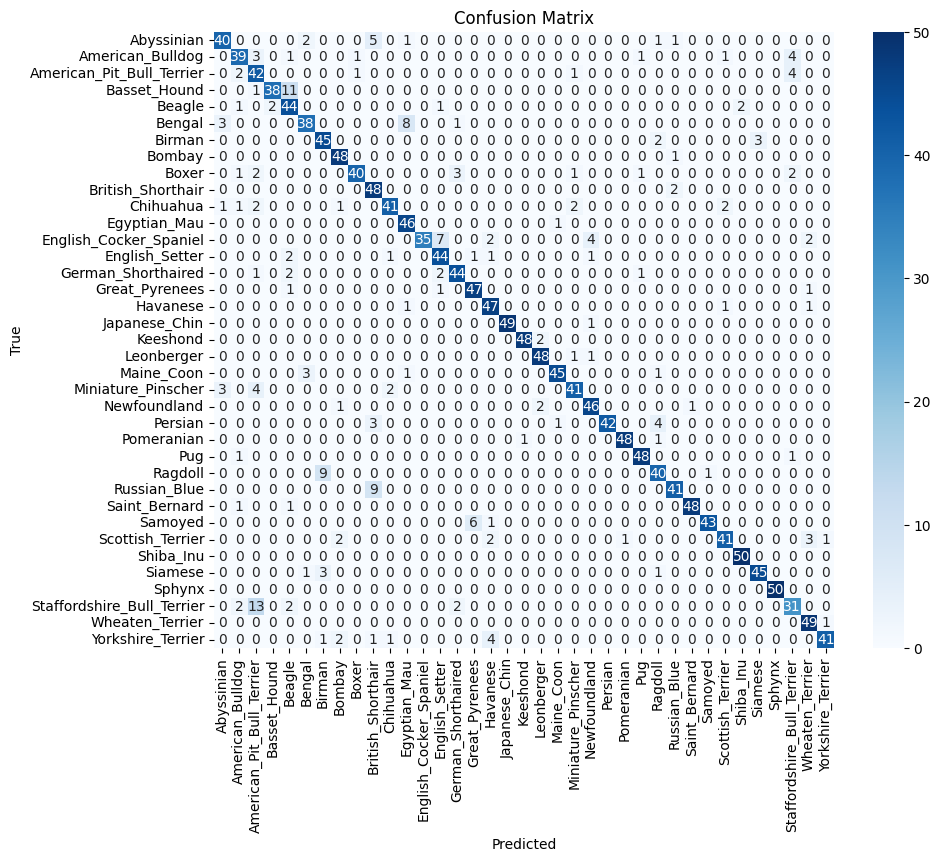

***************************
* Test Accuracy: 0.8776 *
***************************


In [ ]:
resnet_unfreezing_4.load_state_dict(torch.load("unfreezing_4.pth"))
test_acc = test_epoch(resnet_unfreezing_4, resized_test_loader, class_names)

#Add info to Comparison
resnet_unfreezing_4_stat['test_accuracy'] = test_acc
stats.append(resnet_unfreezing_4_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

#### Unfreezing layer3

In [ ]:
unfreezing_3_cfg = {
    #Resizing
    "resize_size": 256,
    "crop_size": 224,

    #Training
    "batch_size": 32,
    "num_epochs": 50,

    #Regularization
    "label_smoothing": 0.02,

    #Data Augmentation
    "mix_up": 0.1,
    "mixup_start_epoch": 10
}

#As Dataloader we can use the ones of previus section since they do not change.

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_unfreezing_3 = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_unfreezing_3.conv1, False)
set_requires_grad(resnet_unfreezing_3.bn1, False)
set_requires_grad(resnet_unfreezing_3.layer1, False)
set_requires_grad(resnet_unfreezing_3.layer2, False)
#layer3 requires gradient (as default) <-- Here the change(s)
#layer4 requires gradient (as default) <-- Here the change(s)

print(resnet_unfreezing_3)
print("\nParameters and FLOPs:\n")
resnet_unfreezing_3_stat = model_stats(resnet_unfreezing_3, (1, 3, unfreezing_3_cfg['crop_size'], unfreezing_3_cfg['crop_size']))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= unfreezing_3_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW([{'params': resnet_unfreezing_3.fc.parameters(), 'lr': 1e-3, "weight_decay": 1e-4},
                         {'params': resnet_unfreezing_3.layer4.parameters(), 'lr': 1e-4, "weight_decay": 1e-3},
                         {'params': resnet_unfreezing_3.layer3.parameters(), 'lr': 1e-5, "weight_decay": 1e-3}])

#Learning Rate Scheduler
steps_per_epoch = len(lowered_augmentations_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= [1e-3, 1e-4, 1e-5],
                        total_steps= unfreezing_3_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_unfreezing_3,
    train_loader= lowered_augmentations_train_loader,
    val_loader= lowered_augmentations_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= unfreezing_3_cfg["num_epochs"],

    mix_up= unfreezing_3_cfg["mix_up"],
    mixup_start_epoch= unfreezing_3_cfg["mixup_start_epoch"],

    device= device,
    save_path= "unfreezing_3.pth",
    history_prefix= "unfreezing_3")

100%|██████████| 115/115 [00:36<00:00,  3.12it/s]


Epoch 1/50
  Train loss: 3.4928, accuracy: 0.0880
  Val   loss: 3.0483, accuracy: 0.2514
  Learning rate: 0.000060


100%|██████████| 115/115 [00:33<00:00,  3.48it/s]


Epoch 2/50
  Train loss: 2.8558, accuracy: 0.3660
  Val   loss: 2.2328, accuracy: 0.6096
  Learning rate: 0.000091


100%|██████████| 115/115 [00:33<00:00,  3.38it/s]


...

Epoch 48/50
  Train loss: 0.6693, accuracy: 0.8941
  Val   loss: 0.6187, accuracy: 0.8806
  Learning rate: 0.000008


100%|██████████| 115/115 [00:33<00:00,  3.43it/s]


Epoch 49/50
  Train loss: 0.8433, accuracy: 0.8644
  Val   loss: 0.6357, accuracy: 0.8768
  Learning rate: 0.000002


100%|██████████| 115/115 [00:43<00:00,  2.66it/s]


Epoch 50/50
  Train loss: 0.6082, accuracy: 0.9099
  Val   loss: 0.6351, accuracy: 0.8811
  Learning rate: 0.000000
Training complete. History saved.


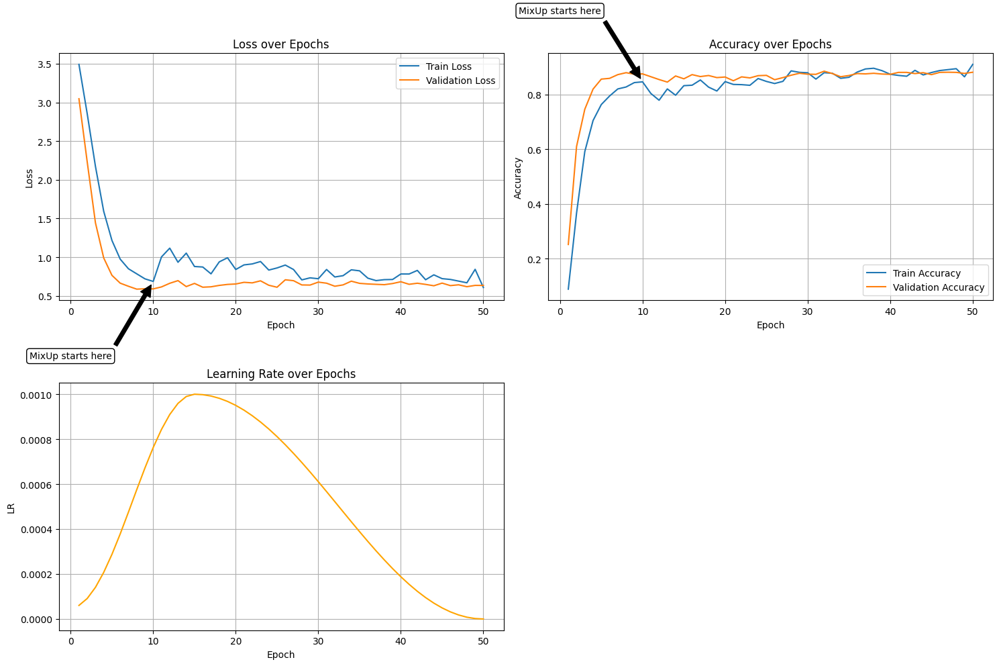

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup= True)

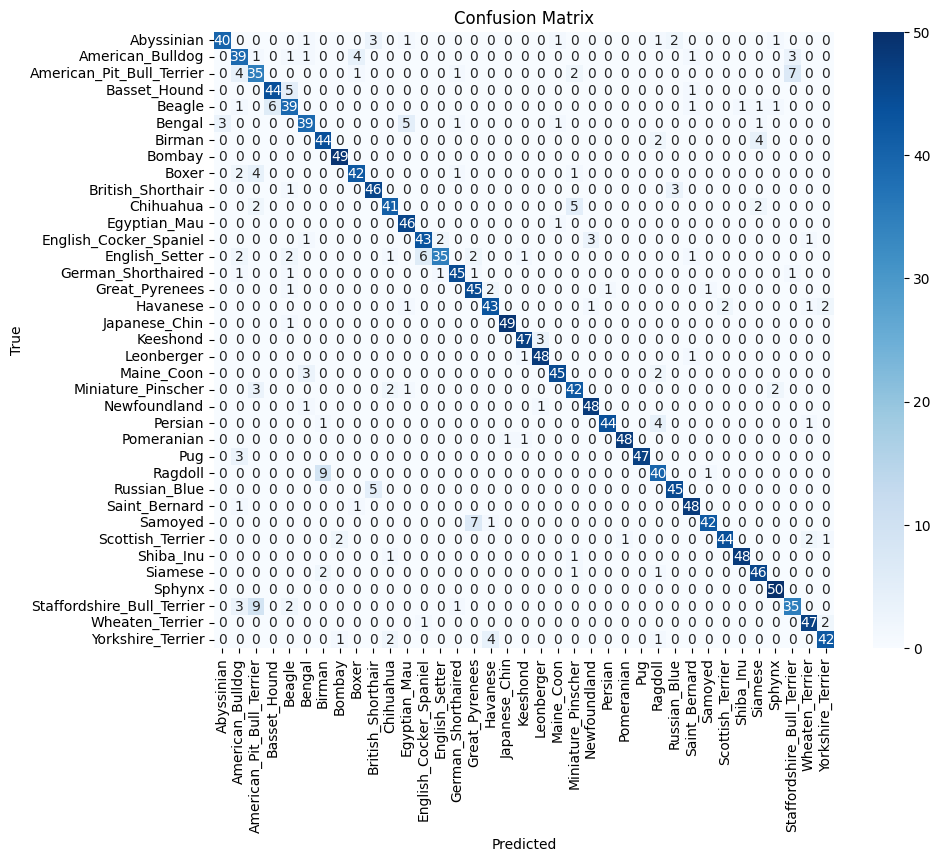

***************************
* Test Accuracy: 0.8776 *
***************************


In [ ]:
resnet_unfreezing_3.load_state_dict(torch.load("unfreezing_3.pth"))
test_acc = test_epoch(resnet_unfreezing_3, resized_test_loader, class_names)

#Add info to Comparison
resnet_unfreezing_3_stat['test_accuracy'] = test_acc
stats.append(resnet_unfreezing_3_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

#### Unfreezing layer2

In [ ]:
unfreezing_2_cfg = {
    #Resizing
    "resize_size": 256,
    "crop_size": 224,

    #Training
    "batch_size": 32,
    "num_epochs": 50,

    #Initial lr
    "lr": 1e-3,

    #Regularization
    "wd": 1e-4,
    "label_smoothing": 0.04,

    #Data Augmentation
    "mix_up": 0.2,
    "mixup_start_epoch": 10
}

#As Dataloader we can use the ones of previus section since they do not change.

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_unfreezing_2 = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_unfreezing_2.conv1, False)
set_requires_grad(resnet_unfreezing_2.bn1, False)
set_requires_grad(resnet_unfreezing_2.layer1, False)
#layer2 requires gradient (as default) <-- Here the change(s)
#layer3 requires gradient (as default) <-- Here the change(s)
#layer4 requires gradient (as default) <-- Here the change(s)

print(resnet_unfreezing_2)
print("\nParameters and FLOPs:\n")
resnet_unfreezing_2_stat = model_stats(resnet_unfreezing_2, (1, 3, unfreezing_2_cfg['crop_size'], unfreezing_2_cfg['crop_size']))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= unfreezing_2_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW([{'params': resnet_unfreezing_2.fc.parameters(), 'lr': 1e-3, "weight_decay": 1e-4},
                         {'params': resnet_unfreezing_2.layer4.parameters(), 'lr': 1e-4, "weight_decay": 1e-3},
                         {'params': resnet_unfreezing_2.layer3.parameters(), 'lr': 5e-5, "weight_decay": 1e-3},
                         {'params': resnet_unfreezing_2.layer2.parameters(), 'lr': 1e-5, "weight_decay": 1e-3}])

#Learning Rate Scheduler
steps_per_epoch = len(lowered_augmentations_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= [1e-3, 1e-4, 5e-5, 1e-5],
                        total_steps= unfreezing_2_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_unfreezing_2,
    train_loader= lowered_augmentations_train_loader,
    val_loader= lowered_augmentations_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= unfreezing_2_cfg["num_epochs"],

    mix_up= unfreezing_2_cfg["mix_up"],
    mixup_start_epoch= unfreezing_2_cfg["mixup_start_epoch"],

    device= device,
    save_path= "unfreezing_2.pth",
    history_prefix= "unfreezing_2")

100%|██████████| 115/115 [00:34<00:00,  3.35it/s]


Epoch 1/50
  Train loss: 3.5006, accuracy: 0.0861
  Val   loss: 3.0871, accuracy: 0.2546
  Learning rate: 0.000060


100%|██████████| 115/115 [00:33<00:00,  3.47it/s]


Epoch 2/50
  Train loss: 2.8669, accuracy: 0.3453
  Val   loss: 2.2529, accuracy: 0.5774
  Learning rate: 0.000091


100%|██████████| 115/115 [00:33<00:00,  3.42it/s]


...

Epoch 48/50
  Train loss: 1.0039, accuracy: 0.8562
  Val   loss: 0.7564, accuracy: 0.8844
  Learning rate: 0.000008


100%|██████████| 115/115 [00:32<00:00,  3.56it/s]


Epoch 49/50
  Train loss: 1.0366, accuracy: 0.8445
  Val   loss: 0.7858, accuracy: 0.8790
  Learning rate: 0.000002


100%|██████████| 115/115 [00:33<00:00,  3.44it/s]


Epoch 50/50
  Train loss: 1.0764, accuracy: 0.8296
  Val   loss: 0.7853, accuracy: 0.8779
  Learning rate: 0.000000
Training complete. History saved.


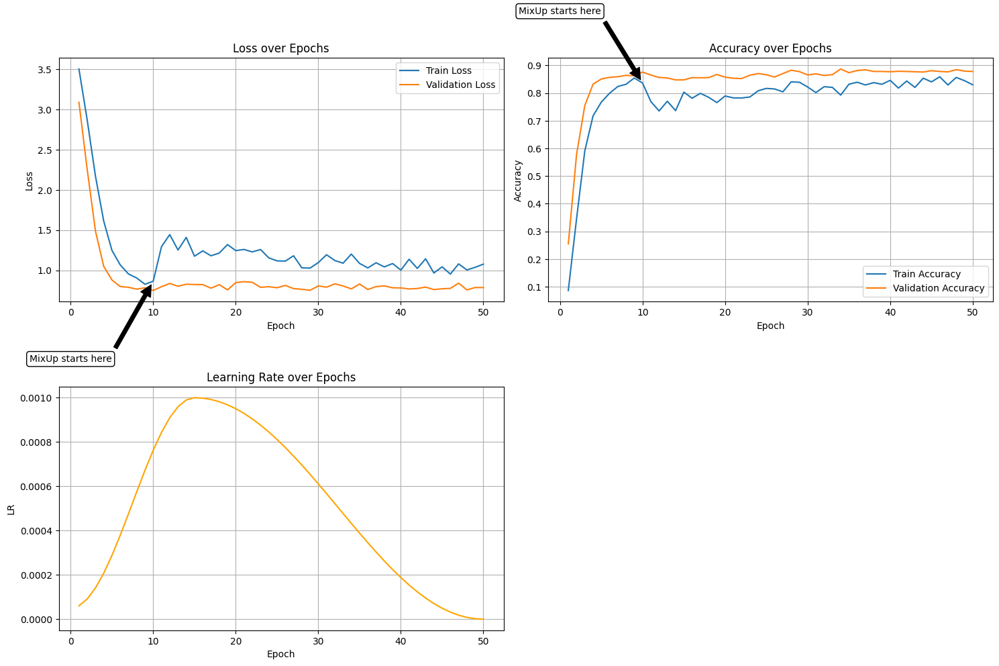

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup= True)

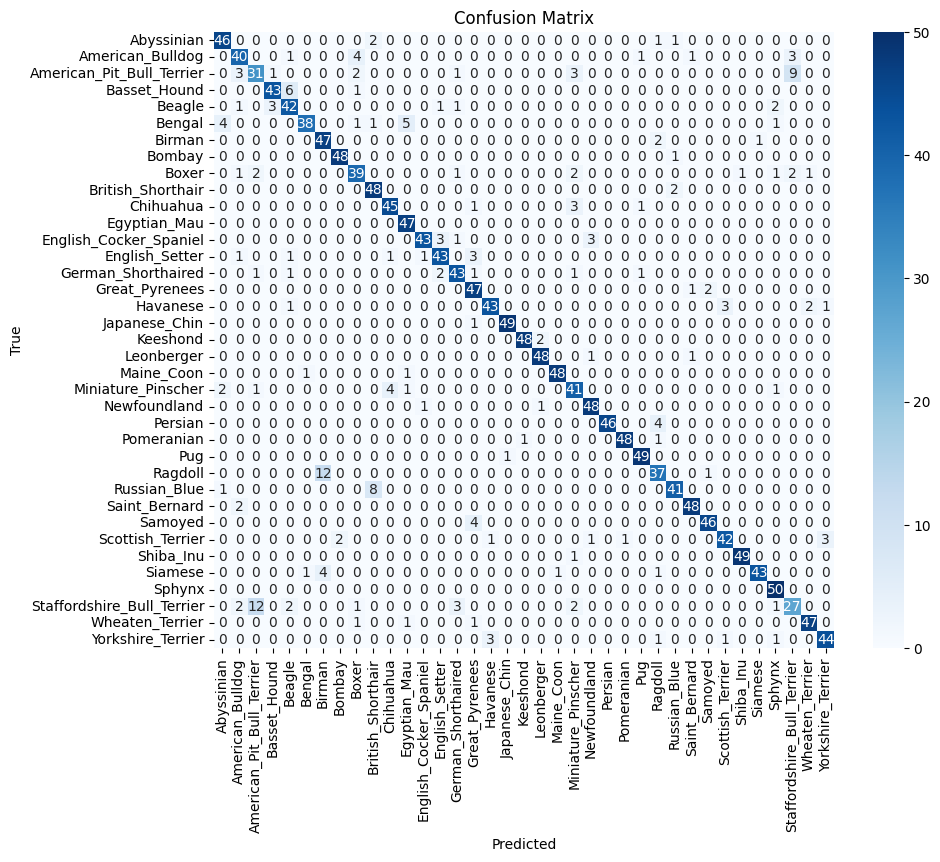

***************************
* Test Accuracy: 0.8841 *
***************************


In [ ]:
resnet_unfreezing_2.load_state_dict(torch.load("unfreezing_2.pth"))
test_acc = test_epoch(resnet_unfreezing_2, resized_test_loader, class_names)

#Add info to Comparison
resnet_unfreezing_2_stat['test_accuracy'] = test_acc
stats.append(resnet_unfreezing_2_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

#### Unfreezing layer1

In [ ]:
unfreezing_1_cfg = {
    #Resizing
    "resize_size": 256,
    "crop_size": 224,

    #Training
    "batch_size": 32,
    "num_epochs": 50,

    #Initial lt
    "lr": 1e-3,

    #Regularization
    "wd": 1e-4,
    "label_smoothing": 0.08,

    #Data Augmentation
    "mix_up": 0.4,
    "mixup_start_epoch": 10
}

In [ ]:
mean_images = [0.484,	0.453,	0.396]
std_images = [0.129,	0.125,	0.137]

unfreezing_1_train_transform = transforms.Compose([ transforms.RandomResizedCrop(unfreezing_1_cfg["crop_size"]),
                                                          transforms.RandomHorizontalFlip(),
                                                          transforms.ColorJitter(brightness= 0.1, contrast= 0.1, saturation= 0.1, hue= 0.1),
                                                          transforms.ToTensor(),
                                                          transforms.Normalize(mean_images, std_images)])

unfreezing_1_val_transform = transforms.Compose([ transforms.Resize(unfreezing_1_cfg["resize_size"]),
                                                        transforms.CenterCrop(unfreezing_1_cfg["crop_size"]),
                                                        transforms.ToTensor(),
                                                        transforms.Normalize(mean_images, std_images)])

# Dataset
train_dataset = OxfordPetDataset(split= "train", transform= unfreezing_1_train_transform)
val_dataset = OxfordPetDataset(split= "val", transform= unfreezing_1_val_transform)
test_dataset = OxfordPetDataset(split= "test", transform= unfreezing_1_val_transform)

# DataLoader
unfreezing_1_train_loader = DataLoader( train_dataset, batch_size= unfreezing_1_cfg["batch_size"], shuffle= True, num_workers= 4)
unfreezing_1_val_loader = DataLoader( val_dataset, batch_size= unfreezing_1_cfg["batch_size"], shuffle= False, num_workers= 4)
unfreezing_1_test_loader = DataLoader( test_dataset, batch_size= unfreezing_1_cfg["batch_size"], shuffle= False, num_workers= 4)

In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1
num_classes = train_dataset.get_num_classes()

resnet_unfreezing_1 = get_model(num_classes, weights).to(device)

set_requires_grad(resnet_unfreezing_1.conv1, False)
set_requires_grad(resnet_unfreezing_1.bn1, False)
#layer1 requires gradient (as default) <-- Here the change(s)
#layer2 requires gradient (as default) <-- Here the change(s)
#layer3 requires gradient (as default) <-- Here the change(s)
#layer4 requires gradient (as default) <-- Here the change(s)

print(resnet_unfreezing_1)
print("\nParameters and FLOPs:\n")
resnet_unfreezing_1_stat = model_stats(resnet_unfreezing_1, (1, 3, unfreezing_1_cfg['crop_size'], unfreezing_1_cfg['crop_size']))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss Function
criterion = nn.CrossEntropyLoss(label_smoothing= unfreezing_1_cfg["label_smoothing"])

#Optimizer
optimizer = optim.AdamW([{'params': resnet_unfreezing_1.fc.parameters(), 'lr': 1e-3, "weight_decay": 1e-4},
                         {'params': resnet_unfreezing_1.layer4.parameters(), 'lr': 1e-4, "weight_decay": 1e-3},
                         {'params': resnet_unfreezing_1.layer3.parameters(), 'lr': 5e-5, "weight_decay": 1e-3},
                         {'params': resnet_unfreezing_1.layer2.parameters(), 'lr': 1e-5, "weight_decay": 1e-3},
                         {'params': resnet_unfreezing_1.layer1.parameters(), 'lr': 5e-6, "weight_decay": 1e-2}])

#Learning Rate Scheduler
steps_per_epoch = len(unfreezing_1_train_loader)
scheduler = OneCycleLR( optimizer,
                        max_lr= [1e-3, 1e-4, 5e-5, 1e-5, 5e-6],
                        total_steps= unfreezing_1_cfg["num_epochs"] * steps_per_epoch,
                        anneal_strategy= 'cos',
                        div_factor= 20)

#Training
train_losses, val_losses, train_accuracies, val_accuracies, learning_rates = train_model(
    model= resnet_unfreezing_1,
    train_loader= unfreezing_1_train_loader,
    val_loader= unfreezing_1_val_loader,

    criterion= criterion,
    optimizer= optimizer,
    scheduler= scheduler,

    num_epochs= unfreezing_1_cfg["num_epochs"],

    mix_up= unfreezing_1_cfg["mix_up"],
    mixup_start_epoch= unfreezing_1_cfg["mixup_start_epoch"],

    device= device,
    save_path= "unfreezing_1.pth",
    history_prefix= "unfreezing_1")

100%|██████████| 115/115 [00:34<00:00,  3.34it/s]


Epoch 1/50
  Train loss: 3.4642, accuracy: 0.1107
  Val   loss: 3.0393, accuracy: 0.2683
  Learning rate: 0.000060


100%|██████████| 115/115 [00:34<00:00,  3.33it/s]


Epoch 2/50
  Train loss: 2.8529, accuracy: 0.4007
  Val   loss: 2.2654, accuracy: 0.6232
  Learning rate: 0.000091


100%|██████████| 115/115 [00:33<00:00,  3.45it/s]


...

Epoch 48/50
  Train loss: 1.5070, accuracy: 0.7698
  Val   loss: 1.0181, accuracy: 0.8768
  Learning rate: 0.000008


100%|██████████| 115/115 [00:32<00:00,  3.50it/s]


Epoch 49/50
  Train loss: 1.5453, accuracy: 0.7599
  Val   loss: 1.0495, accuracy: 0.8746
  Learning rate: 0.000002


100%|██████████| 115/115 [00:34<00:00,  3.36it/s]


Epoch 50/50
  Train loss: 1.4715, accuracy: 0.7748
  Val   loss: 1.0322, accuracy: 0.8768
  Learning rate: 0.000000
Training complete. History saved.


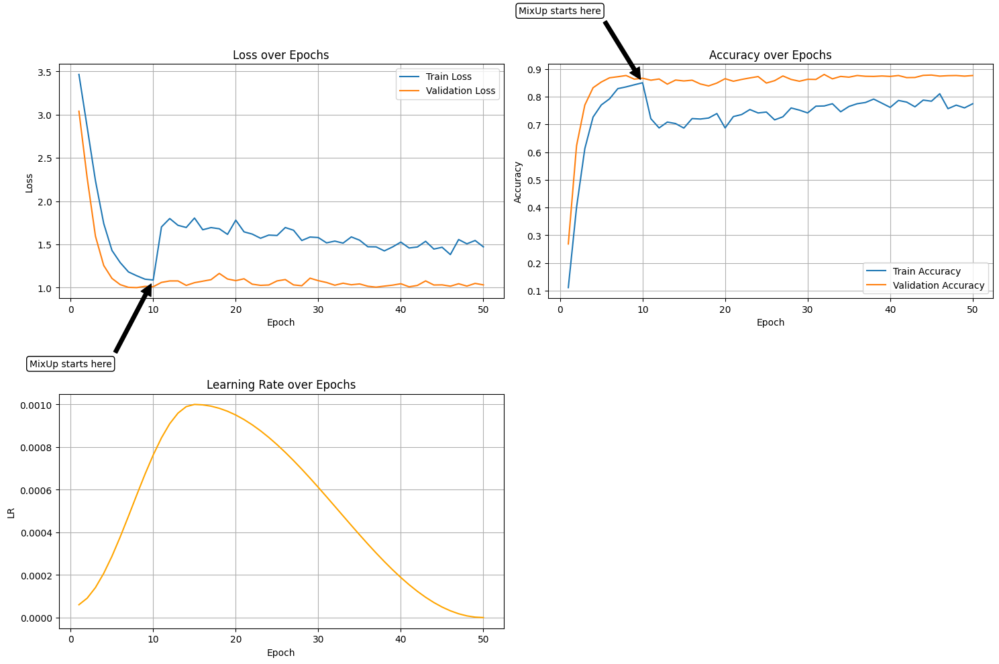

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies, learning_rates, mixup= True)

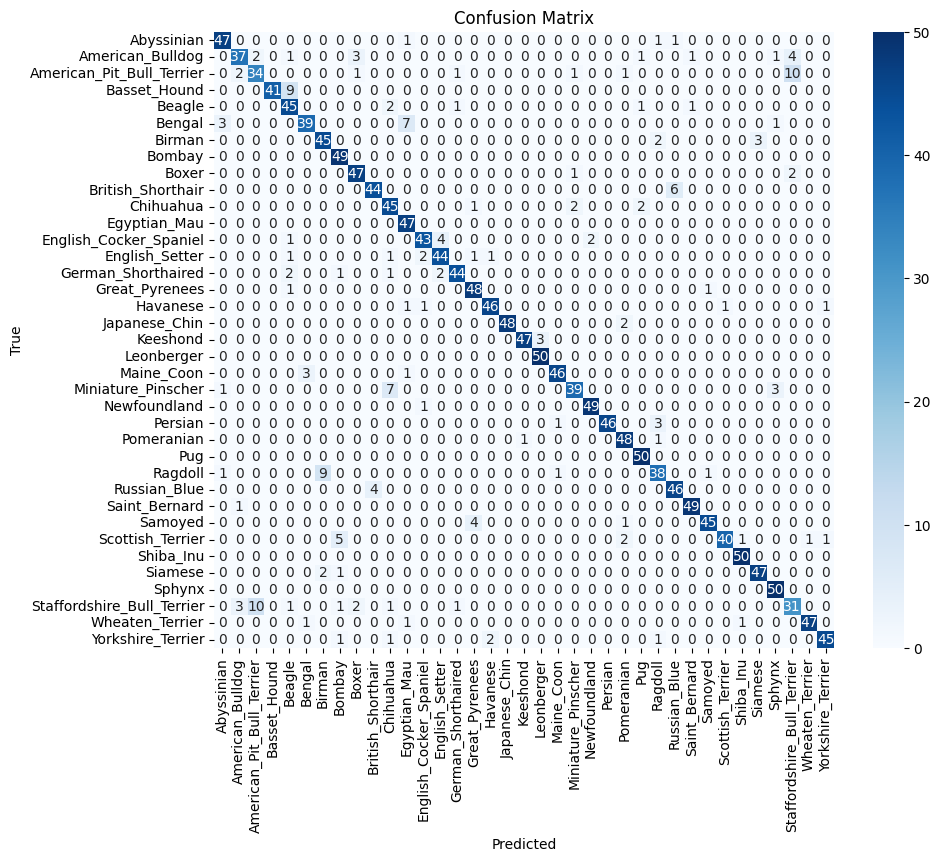

***************************
* Test Accuracy: 0.8971 *
***************************


In [ ]:
resnet_unfreezing_1.load_state_dict(torch.load("unfreezing_1.pth"))
test_acc = test_epoch(resnet_unfreezing_1, unfreezing_1_test_loader, class_names)

#Add info to Comparison
resnet_unfreezing_1_stat['test_accuracy'] = test_acc
stats.append(resnet_unfreezing_1_stat)

train_accuracies_list.append(train_accuracies)
val_accuracies_list.append(val_accuracies)
train_losses_list.append(train_losses)
val_losses_list.append(val_losses)

## ResNet18 Transfer Learning Experiment Summary

This experiment investigates a structured transfer learning approach using a modified **ResNet18** for a 37-class classification problem. The objective is to progressively enhance performance through a combination of data preprocessing, regularization tuning, and layer-wise fine-tuning, while analyzing the impact on model complexity (trainable parameters and FLOPs).

### Performance and Training Dynamics

In [ ]:
labels = ['Original Hyperparameters', 'Resized', 'Lowered Augmentations', 'No Label Smoothing and Mixup', "Unfreezing layer4", "Unfreezing layer3", "Unfreezing layer2", "Unfreezing layer1"]
create_stats_dataframe(stats[0:4], labels[0:4])

,Name,Test Accuracy,% Change (Accuracy),Parameters,% Change (Parameters),MFLOPs,% Change (FLOPs)
0,Original Hyperparameters,62.57,+0.00%,"18,981",+0.00%,"1,189",+0.00%
1,Resized,85.32,+36.36%,"18,981",+0.00%,"3,643",+206.24%
2,Lowered Augmentations,88.03,+40.69%,"18,981",+0.00%,"3,643",+206.24%
3,No Label Smoothing and Mixup,89.17,+42.51%,"18,981",+0.00%,"3,643",+206.24%


After fine-tuning the pretrained **ResNet-18** (`Original Hyperparameters`) using the same hyperparameters employed in the baseline model we progressively introduced:

1. **Resized Inputs (`Resized`):**  
   Adjusting the input resolution to the standard 224×224 used during ImageNet pretraining significantly improved alignment between data and pretrained filters.  
   - **Accuracy:** Increased from 62.57% to **85.32%** (+36.36%)  
   - **MFLOPs:** Increased from 1,189 to 3,643 (+206.24%) due to higher resolution in imput images

2. **Lowered Augmentations (`Lowered Augmentations`):**  
   Reducing augmentation strength improved consistency between training and validation data.  
   - **Accuracy:** **88.03%** (+40.69%)  
   - Parameters: unchanged  
   - FLOPs: unchanged (+206.24% vs baseline)   

3. **Removed Regularization (`No Label Smoothing and Mixup`):**  
   Disabling these regularizations allowed the model to make more confident predictions.  
   - **Accuracy:** **89.17%** (+42.51%)  
   - Parameters: unchanged  
   - FLOPs: unchanged (+206.24% vs baseline)  

Together, these optimizations produced a **+42.5% improvement in test accuracy** without altering model size.

In [ ]:
create_stats_dataframe(stats[4:], labels[4:], relative=True)

,Name,Test Accuracy,% Change (Accuracy),Parameters,% Change (Parameters),MFLOPs,% Change (FLOPs)
0,Unfreezing layer4,87.76,,"8,412,709",,"10,441",
1,Unfreezing layer3,87.70,-0.07%,"10,512,421",+24.96%,"12,142",+16.29%
2,Unfreezing layer2,88.41,+0.81%,"11,037,989",+5.00%,"12,567",+3.51%
3,Unfreezing layer1,89.71,+1.47%,"11,185,957",+1.34%,"12,687",+0.95%




> Please note that in this table the `% Changes` are relative to the previus row and not to the baseline.



After reaching strong performance through hyperparameter tuning, deeper layers of the pretrained network were gradually **unfrozen** and fine-tuned with *layer-specific learning rates* to promote domain adaptation while minimizing the risk of overfitting.

Using **different learning rates for different layers** is a key strategy in transfer learning:  
- **Earlier layers** (closer to the input) capture **generic low-level features** such as edges and textures, which are often transferable across datasets. These layers require **very small learning rates** to prevent the pretrained filters from being distorted.  
- **Deeper layers**, on the other hand, learn **task-specific representations**, so they benefit from **higher learning rates** to adapt more aggressively to the new data distribution.  

These results show a **progressive increase in accuracy** as more layers are unfrozen, reaching a peak of **89.71%** when fine-tuning up to *layer1*.  
At the same time, the total number of parameters increased from **8.41M to 11.19M (+33%)**, and the computational cost rose from **10.44 to 12.69 MFLOPs (+21%)**.  
This confirms that while fine-tuning deeper layers improves representational power, it also introduces higher computational and memory costs, although still moderate compared to the performance gain.


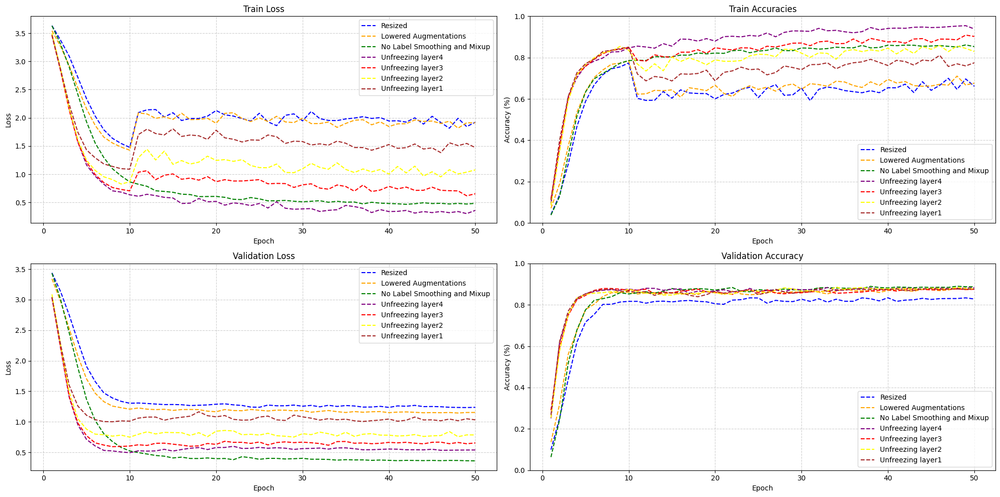

In [ ]:
colors = ['black', 'blue', 'orange', 'green', 'purple', 'red', 'yellow', 'brown']
linestyles = ['-', '--', '--', '--', '--', '--', '--', '--']

plot_training_results(train_accuracies_list, val_accuracies_list, train_losses_list, val_losses_list, labels, colors, linestyles, figsize=(20, 10))

Analysis of **training and validation loss/accuracy plots** across all configurations reveals:
- The **Resized** and **Lowered Augmentation** settings stabilized convergence and reduced oscillations.  
- Removing regularization increased training confidence without visible overfitting.  
- During **layer unfreezing**, validation accuracy followed training accuracy closely, confirming successful domain adaptation.  
- The final configuration (unfreezing up to *layer1*) achieved the best balance between accuracy, generalization, and efficiency.

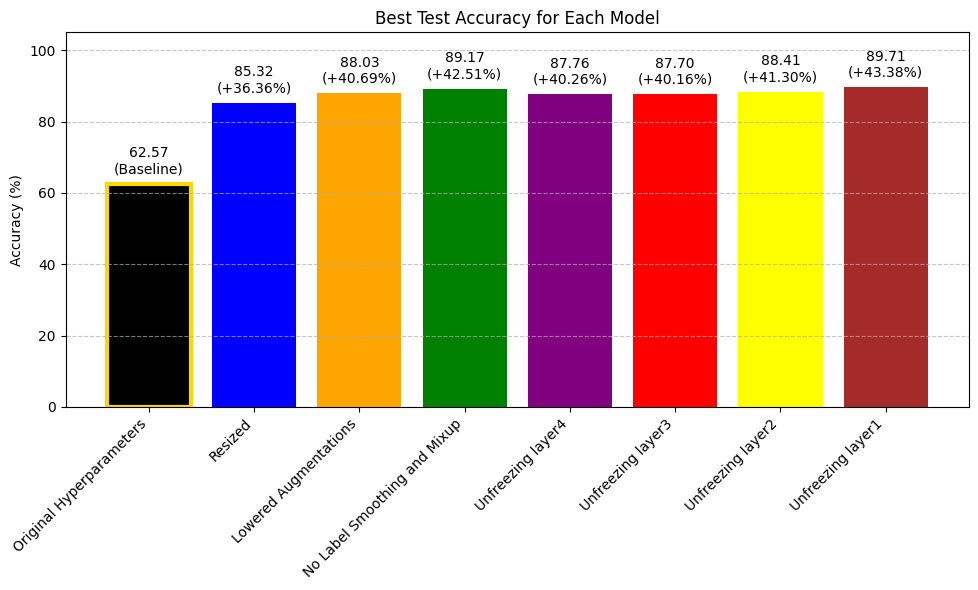

In [ ]:
test_accuracies = [d["test_accuracy"] for d in stats]
plot_test_accuracies(test_accuracies, labels, colors)

### Overall Conclusions

- Fine-tuning pretrained architectures such as **ResNet-18** with **properly adjusted inputs and controlled augmentations** yields substantial accuracy improvements.  
- **Progressive unfreezing** is a reliable strategy to refine pretrained features while minimizing the probability that the pretrainde network forget high-level feature.  
- The greatest improvements stemmed from aligning preprocessing and augmentation strategies with the pretrained model’s original setup rather than from structural modifications.  
- The final fine-tuned configuration achieved a **test accuracy of 89.71%**, marking a significant advancement over both the baseline and initial fine-tuning stages.

# Final Conclusions and Comparison

Compared to the **custom model trained from scratch** in Part 1, the fine-tuned **ResNet-18** demonstrated **significantly superior performance, faster convergence, and better generalization** despite being trained under similar conditions. Unlike the scratch model, which had to learn **all visual representations from zero**, the pretrained ResNet-18 already possessed **rich hierarchical filters**—from low-level edge detectors to high-level semantic encoders—learned from millions of diverse ImageNet images. This prior knowledge enabled the network to **adapt efficiently to the new domain** with minimal adjustments, achieving higher accuracy within fewer epochs.

The architecture used in Part 1 was intentionally designed to be simple and progressively developed based on performance needs. A lightweight convolutional neural network (CNN) was initially implemented, and its complexity was only increased if required to surpass the given accuracy threshold. This incremental design strategy ensured **stable training and reduced overfitting risk** on the relatively small dataset. Furthermore, since Part 2 employed a pretrained ResNet-18 for transfer learning, **there was no purpose in replicating a deep residual network architecture from scratch**, especially given the computational cost and limited training data.

Moreover, the fine-tuning process allows for a flexible adaptation strategy depending on the task complexity and dataset size. By selectively updating only the final classification layers or progressively unfreezing deeper residual blocks, it is possible to **control the trade-off between specialization and generalization**. In this project, fine-tuning enabled the model to retain the strong visual priors learned from ImageNet while still adapting to the characteristics of the target dataset.

Another key advantage of transfer learning is its **computational efficiency**. Training a deep network from scratch typically requires substantial time and hardware resources. In contrast, fine-tuning ResNet-18 reduced training time significantly thanks to the reuse of pretrained weights, faster convergence, and reduced need for extensive hyperparameter exploration. This efficiency made transfer learning a practical and effective solution for achieving high performance under real-world time and resource constraints.

It is also important to note that while the fine-tuned ResNet-18 involves a **larger number of parameters** than the shallow custom model (due to its deeper and more complex architecture), the **training time and effective computational cost** were **drastically lower**.  
Because the pretrained weights already encode a strong initialization, the optimization converges much faster, often within a fraction of the epochs required by a network trained from scratch.  

Moreover, although the theoretical MFLOPs of ResNet-18 are higher, the **practical FLOPs per epoch** and **total training compute** are reduced thanks to the **rapid convergence** and the **lower number of required iterations** to reach optimal performance.

It is important to clarify the scope of the ablation studies conducted in this project. The experiments were limited to **modifying network parameters and architectures** without performing a full hyperparameter optimization or fine-tuning each configuration to its optimal settings. As a result, the observed performance differences primarily reflect **relative trends and sensitivities** rather than the absolute best achievable performance for each variant. This limitation should be considered when interpreting the results, as some architectures or parameter combinations might have performed slightly better if fully tuned. The ablation studies nonetheless provide valuable insights into **which architectural choices and modifications influence model behavior** and which directions are most promising for further optimization.

Overall, Part 2 highlights that leveraging pretrained models—combined with systematic fine-tuning and hyperparameter optimization—is the most practical and powerful approach to achieving high performance, stability, and efficiency in modern deep learning pipelines.
